<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%207/W07_L4_Video_Understanding_with_CNNs_and_RNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=mHiCDj4hUsU) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%207/NPTEL_Jul24_DL4CV_W07_P04.pdf)

In [1]:
# Week 7, Lecture 4: Video understanding using CNN's and RNN's
from IPython.display import HTML, display

VIDEO_ID = "mHiCDj4hUsU"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 7, Lecture 4: Video Understanding using CNNs and RNNs

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§7.4 Video Understanding**.

This notebook builds one small synthetic video dataset in which a single frame cannot decide the label, and then trains every architecture in the lecture on it: a single-frame CNN, the late, early and slow fusion variants of Karpathy et al., a 3D CNN, a two-stream network and a CNN + LSTM (LRCN). Every model is measured on the same test clips, and then on the same clips played backwards, which answers the slide's homework with numbers.

**What you will learn**

- Why **motion**, not appearance, carries the label in many videos, and how to build a dataset in which a single frame is provably uninformative.
- The lecture's taxonomy: **time as another dimension** (a 3D convolution over $(N, C, T, H, W)$) versus **time as a separate entity** (2D convolution per frame, with optical flow or a recurrent net doing the temporal work).
- The **fusion** variants of Karpathy et al.: single frame, late, early and slow fusion, built as small trained models.
- **3D convolution** from scratch, verified against `F.conv3d`, and the layer arithmetic of Ji et al. (2012) including the 33-map **hardwired layer** built from gray levels, gradients and a from-scratch Lucas-Kanade **optical flow**.
- The **two-stream network**: a spatial stream on RGB and a temporal stream on $L$ stacked motion frames, fused by averaging class scores, $p = \tfrac12 (p_{\text{spatial}} + p_{\text{temporal}})$.
- **LRCN**: a per-frame CNN with shared weights feeding an LSTM that predicts at every timestep, why it sits on a chance plateau for longer than the models that detect motion locally, and how its accuracy grows frame by frame.
- What every model does when a clip is **reversed** in time.

**Contents**

0. A synthetic video dataset: shapes moving on a torus
1. Why a single frame is not enough
2. The taxonomy: two ways to handle time
3. Fusing frames inside a CNN: late, early and slow fusion
4. 3D convolution
5. The two-stream network
6. CNN + LSTM: LRCN
7. All models on one table
8. The slide's homework: reversed clips
9. Explore and verify

**How to run**  Everything is tiny and runs in a few minutes on **Colab CPU or GPU** (no GPU needed). No dataset is downloaded; the clips are generated in the notebook. Run the setup cell first, then go top to bottom.

## Review

The previous lecture built LSTMs and GRUs and explained why their gated, additive cell state gives gradients a highway through time; the GRU protects that highway with its update gate, for the same reason the LSTM does with its forget gate. So far in Week 7 the elements of a sequence have been *vectors*. This lecture asks what changes when every element is an *image*, that is, when the sequence is a video, and whether the two tools we already have, convolution for images and recurrence for sequences, can be combined. The lecture gives two families of answers: let the convolution itself span time, or process frames one at a time and hand the temporal work to something else, either optical flow or an RNN. The question this notebook answers is which of these actually learns motion, and what each one does when time runs backwards.

## Setup

In [2]:
# Run this cell first. Works on Colab (CPU or GPU) and locally.
%matplotlib inline
import sys, math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ipywidgets ships with Colab; install only if it is missing.
try:
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox, fixed
except ImportError:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox, fixed

def set_seed(seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
set_seed(0)

# Device: this line works unchanged on CPU and GPU runtimes.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_printoptions(precision=4, sci_mode=False)
plt.rcParams['figure.dpi'] = 100

# On some CPUs (Apple Silicon among them) conv2d is routed through NNPACK, which is several times slower
# than PyTorch's default kernel for the small convolutions used here. Turning it off changes no numbers.
try:
    torch.backends.nnpack.set_flags(False)
except AttributeError:
    pass

def count_params(module):
    """Number of trainable parameters in a module."""
    return sum(p.numel() for p in module.parameters())

print('torch', torch.__version__, '| device:', device)

torch 2.8.0 | device: cpu


## 0. A synthetic video dataset: shapes moving on a torus

The lecture opens with two YouTube clips (credited to Smarter Every Day and Veritasium) and a question: *why do we need to understand a video, and how?* What any such example has in common with the next is that the interesting thing is not in any one frame. It is the **displacement of points over time**, that is, motion. A dataset that makes this precise needs one property above all: **a single frame must carry no information about the label**. Then any model that reaches above chance has, by construction, read the motion.

Each clip here has $T = 8$ frames of $32 \times 32$ RGB pixels. One shape (a square, a disc or a plus, 5 to 8 pixels across, in a random color) moves with a constant velocity on a **torus**: the frame wraps around at its edges, so a shape leaving on the right re-enters on the left. The label is the **motion class**, one of 4 directions times 2 speeds:

| class | direction | speed (pixels per frame) |
|---|---|---|
| 0, 1 | right | 1 (slow), 3 (fast) |
| 2, 3 | left | 1, 3 |
| 4, 5 | up | 1, 3 |
| 6, 7 | down | 1, 3 |

Three design decisions matter for everything that follows:

- **Shape, color and start position are drawn independently of the label.** Because the boundary is periodic, the start position is uniform over the whole frame with no edge effects, and the position at frame $t$ (start plus $t$ times the velocity, modulo 32) is again uniform. So every single frame has exactly the same distribution under every class. A per-frame classifier cannot beat $1/8$.
- **Reversing time maps a class to another class.** Playing a "right, slow" clip backwards gives a "left, slow" clip. Direction is **reversal-sensitive**; speed is **reversal-invariant**. That split is what the slide's homework is about.
- **Torus translations are free augmentation.** Rolling every frame of a clip by the same offset leaves the motion, and hence the label, unchanged, so the training loop can translate clips at random.

A fresh sample of sensor noise is added to each frame, so consecutive frames are never exact copies of each other.

In [3]:
T, S = 8, 32                                   # frames per clip, frame side
DIRECTIONS = {'right': (0, 1), 'left': (0, -1), 'up': (-1, 0), 'down': (1, 0)}   # (dy, dx) per frame
DIR_NAMES = list(DIRECTIONS)
SPEEDS = [1, 3]                                # pixels per frame
CLASS_NAMES = [f'{d} {"slow" if v == 1 else "fast"}' for d in DIR_NAMES for v in SPEEDS]
N_CLASSES = len(CLASS_NAMES)                   # 8 = 4 directions x 2 speeds

def shape_mask(kind, size, yy, xx, cy, cx):
    """Boolean (S, S) mask of a square (kind 0), disc (1) or plus (2) of the given size centred at (cy, cx)."""
    dy, dx, r = yy - cy, xx - cx, size / 2
    if kind == 0:
        return (dy.abs() <= r) & (dx.abs() <= r)
    if kind == 1:
        return dy ** 2 + dx ** 2 <= r ** 2
    return ((dy.abs() <= 1) & (dx.abs() <= r)) | ((dx.abs() <= 1) & (dy.abs() <= r))

def make_clips(n, seed):
    """n clips of T frames. Returns X (n, T, 3, S, S) in [0, 1], class y (n,), direction index, speed index."""
    g = torch.Generator().manual_seed(seed)
    yy, xx = torch.meshgrid(torch.arange(S, dtype=torch.float32),
                            torch.arange(S, dtype=torch.float32), indexing='ij')
    X = torch.zeros(n, T, 3, S, S)
    d_idx = torch.randint(0, 4, (n,), generator=g)
    v_idx = torch.randint(0, 2, (n,), generator=g)
    for i in range(n):
        kind = int(torch.randint(0, 3, (1,), generator=g))
        size = float(torch.randint(5, 9, (1,), generator=g))
        cy, cx = (torch.rand(2, generator=g) * S).long().tolist()          # uniform start position
        mask = shape_mask(kind, size, yy, xx, S / 2, S / 2)
        mask = torch.roll(mask, shifts=(cy - S // 2, cx - S // 2), dims=(0, 1))   # torus: wraps around
        color = 0.4 + 0.6 * torch.rand(3, generator=g)
        background = 0.08 * torch.rand(3, S, S, generator=g)
        dy, dx = DIRECTIONS[DIR_NAMES[int(d_idx[i])]]
        v = SPEEDS[int(v_idx[i])]
        for t in range(T):
            m_t = torch.roll(mask, shifts=(t * v * dy, t * v * dx), dims=(0, 1))
            X[i, t] = torch.where(m_t[None], color[:, None, None].expand(3, S, S), background)
    X = (X + 0.03 * torch.randn(X.shape, generator=g)).clamp(0, 1)         # sensor noise, fresh per frame
    return X, 2 * d_idx + v_idx, d_idx, v_idx

t0 = time.time()
Xtr, ytr, dir_tr, spd_tr = make_clips(2000, seed=0)
Xte, yte, dir_te, spd_te = make_clips(400, seed=1)
print(f'generated train {tuple(Xtr.shape)} and test {tuple(Xte.shape)} in {time.time() - t0:.1f} s '
      f'({(Xtr.numel() + Xte.numel()) * 4 / 1e6:.0f} MB of float32 frames)')
Xtr, ytr, dir_tr, spd_tr = Xtr.to(device), ytr.to(device), dir_tr.to(device), spd_tr.to(device)
Xte, yte, dir_te, spd_te = Xte.to(device), yte.to(device), dir_te.to(device), spd_te.to(device)

print('\n  class  name          train  test')
for c, name in enumerate(CLASS_NAMES):
    print(f'  {c:5d}  {name:12s} {int((ytr == c).sum()):5d} {int((yte == c).sum()):5d}')

generated train (2000, 8, 3, 32, 32) and test (400, 8, 3, 32, 32) in 0.7 s (236 MB of float32 frames)

  class  name          train  test
      0  right slow     251    58
      1  right fast     256    53
      2  left slow      252    56
      3  left fast      255    41
      4  up slow        235    45
      5  up fast        239    46
      6  down slow      241    58
      7  down fast      271    43


### The clips, as filmstrips

One row per clip, one column per frame. Read a row left to right and the motion is obvious; cover all but one column and it is gone. The "fast" clips travel 21 pixels in 8 frames, so on a 32-pixel torus most of them cross an edge and re-enter on the other side (only a shape that starts more than 21 pixels plus its radius from the far edge stays in view throughout).

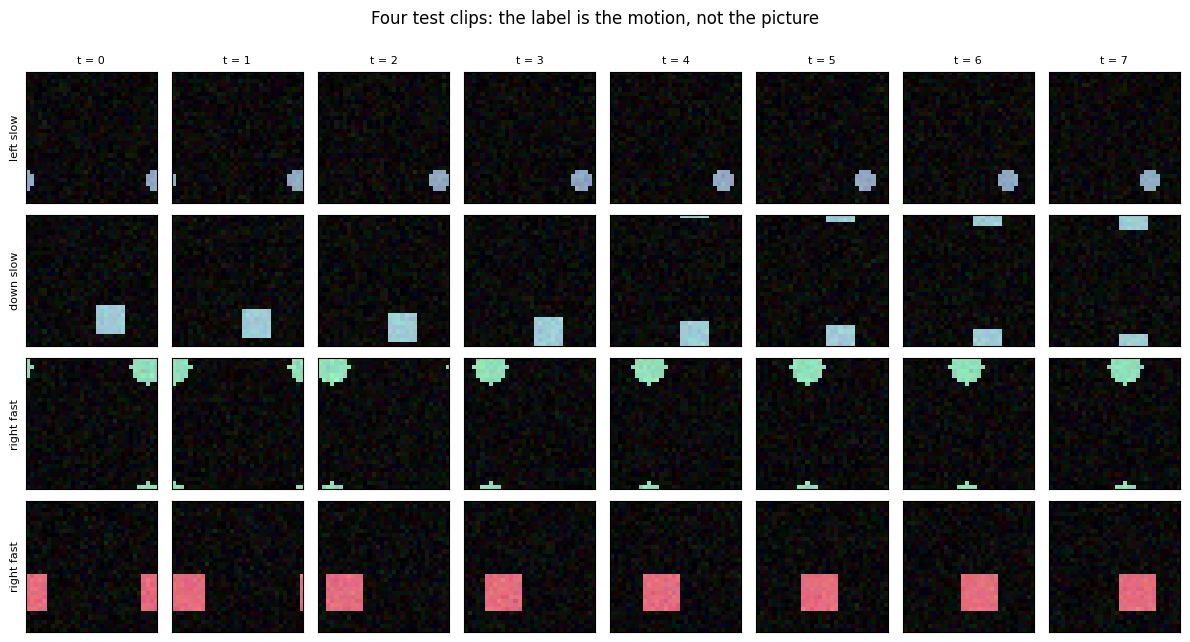

In [4]:
def show_filmstrip(axes, clip, label=None):
    """Draw the T frames of one clip, a (T, 3, S, S) tensor, along a row of axes."""
    clip = clip.detach().cpu()
    for t, ax in enumerate(axes):
        ax.imshow(clip[t].permute(1, 2, 0).numpy())
        ax.set_xticks([]); ax.set_yticks([])
    if label is not None:
        axes[0].set_ylabel(label, fontsize=8)

fig, axes = plt.subplots(4, T, figsize=(12, 6.4))
for r in range(4):
    show_filmstrip(axes[r], Xte[r], label=CLASS_NAMES[int(yte[r])])
for t in range(T):
    axes[0, t].set_title(f't = {t}', fontsize=8)
plt.suptitle('Four test clips: the label is the motion, not the picture', y=1.0)
plt.tight_layout(); plt.show()

### A single frame carries nothing

The claim above was that every frame has the same distribution under every class. Two quick checks on frame 0 and on frame 4. First, the class-conditional mean frames should be the same flat image for all eight classes, up to sampling noise: with about 50 test clips per class, the difference of two class means has a standard deviation of $\sigma \sqrt{2 / 50}$ per pixel, where $\sigma$ is the pixel spread across clips, so the *mean* absolute gap between two class-mean frames should be about $0.8$ of that (the mean of $|z|$ for a Gaussian $z$). Second, the *largest* gap over all 3072 pixel channels and 28 class pairs is the maximum of about 86,000 such noisy differences, and the maximum of $K$ Gaussians is about $\sqrt{2 \ln K}$ standard deviations, so it should come out a little below $\sigma \sqrt{2/50} \sqrt{2 \ln K}$. Both numbers come out as noise predicts: there is nothing for a per-frame classifier to find.

In [5]:
n_per_class = len(Xte) / N_CLASSES
for t in (0, T // 2):
    means = torch.stack([Xte[yte == c, t].mean(0) for c in range(N_CLASSES)])   # (8, 3, S, S)
    iu = torch.triu_indices(N_CLASSES, N_CLASSES, 1)
    pair_gap = (means[:, None] - means[None]).abs()[iu[0], iu[1]]                # (28 class pairs, 3, S, S)
    spread = Xte[:, t].std(0).mean()                                             # pixel spread across clips, sigma
    noise_sd = spread * math.sqrt(2 / n_per_class)                               # sd of a difference of two class means
    exp_mean = noise_sd * math.sqrt(2 / math.pi)                                  # expected mean |gap| if the classes were identical
    exp_max = noise_sd * math.sqrt(2 * math.log(pair_gap.numel()))                # rough size of the largest of K such gaps
    print(f'frame {t}: mean |gap| between class-mean frames = {pair_gap.mean():.4f}   '
          f'expected from noise alone with {n_per_class:.0f} clips per class = {exp_mean:.4f}')
    print(f'         largest gap over all {pair_gap.numel():,} pixels and class pairs = {pair_gap.max():.3f}   '
          f'noise predicts at most about {exp_max:.3f}   (pixel spread across clips = {spread:.3f})')
print('\nthe start position is uniform on the torus and independent of the label, so frame t is too:')
print('a classifier that sees one frame cannot do better than chance, 1/8 = 0.125')

frame 0: mean |gap| between class-mean frames = 0.0207   expected from noise alone with 50 clips per class = 0.0215
         largest gap over all 86,016 pixels and class pairs = 0.108   noise predicts at most about 0.128   (pixel spread across clips = 0.135)
frame 4: mean |gap| between class-mean frames = 0.0208   expected from noise alone with 50 clips per class = 0.0215
         largest gap over all 86,016 pixels and class pairs = 0.109   noise predicts at most about 0.129   (pixel spread across clips = 0.135)

the start position is uniform on the torus and independent of the label, so frame t is too:
a classifier that sees one frame cannot do better than chance, 1/8 = 0.125


### Widget 1: the clip player

Drag `t` to scrub through a clip and `clip` to change clips. The middle panel is the difference between frame $t$ and frame $t-1$: a signed "where did it come from, where did it go" picture that will become the temporal stream's input in section 5. The right panel is the maximum over all eight frames, the trace the shape leaves. Notice that the trace of a "right" clip and a "left" clip look identical: the trace throws away order, exactly as a frame-order-ignoring model would.

In [6]:
def clip_player(clip=0, t=3):
    x = Xte[clip].detach().cpu()
    fig, axes = plt.subplots(1, 3, figsize=(9, 3.1))
    axes[0].imshow(x[t].permute(1, 2, 0).numpy()); axes[0].set_title(f'frame t = {t}')
    if t > 0:
        d = (x[t] - x[t - 1]).mean(0)
        axes[1].imshow(d.numpy(), cmap='RdBu_r', vmin=-0.8, vmax=0.8)
        axes[1].set_title(f'frame {t} minus frame {t - 1}')
    else:
        axes[1].imshow(torch.zeros(S, S).numpy(), cmap='RdBu_r', vmin=-0.8, vmax=0.8)
        axes[1].set_title('no previous frame')
    axes[2].imshow(x.amax(0).permute(1, 2, 0).numpy()); axes[2].set_title('max over all 8 frames (the trace)')
    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])
    plt.suptitle(f'clip {clip}: {CLASS_NAMES[int(yte[clip])]}', y=1.02)
    plt.tight_layout(); plt.show()

interact(clip_player, clip=IntSlider(min=0, max=15, step=1, value=0),
                      t=IntSlider(min=0, max=T - 1, step=1, value=3));

interactive(children=(IntSlider(value=0, description='clip', max=15), IntSlider(value=3, description='t', max=…

## 1. Why a single frame is not enough

The thing that distinguishes video from images is the **displacement of points over time**. Here is the smallest possible illustration: a dot moving right and the same dot moving left produce clips that contain *exactly the same set of frames*, only in a different order. Summing the frames over time gives the same image for both. Any model that ignores frame order, and a single-frame model is the extreme case, cannot tell them apart.

In [7]:
# A single frame cannot distinguish two clips that differ only in the direction of motion.
def moving_dot(direction, T_=8, S_=16):
    v = torch.zeros(T_, S_, S_)
    for t in range(T_):
        pos = t if direction > 0 else (T_ - 1 - t)
        v[t, S_ // 2, pos * 2] = 1.0
    return v

forward_clip, backward_clip = moving_dot(+1), moving_dot(-1)

same_frames = sorted(forward_clip.reshape(8, -1).sum(1).tolist()) == \
              sorted(backward_clip.reshape(8, -1).sum(1).tolist())
identical_sum = torch.allclose(forward_clip.sum(0), backward_clip.sum(0))

print(f'the two clips contain the same set of frames : {same_frames}')
print(f'summing over time gives the same image       : {identical_sum}')
print(f'but the clips are different                  : {not torch.equal(forward_clip, backward_clip)}')
print('\nany model that ignores frame order cannot tell these apart')

the two clips contain the same set of frames : True
summing over time gives the same image       : True
but the clips are different                  : True

any model that ignores frame order cannot tell these apart


### 1a. One training loop for every model

Every model in this notebook is trained the same way so that the comparisons mean something: Adam, cross-entropy, batches of 64 clips, and the torus-roll augmentation described in section 0 (each clip in the batch is translated by a random offset, the same offset for all of its frames). The number of steps and the learning rate are the only things that vary between models, and both are visible in every run: models that compare global frame descriptions (late fusion, the LRCN) need a longer budget than models that detect motion locally, and the notebook gives it to them. Each log line prints the mean training loss since the previous line and the test accuracy; test accuracy is recorded for the learning curves only, and no decision is ever made from it. The per-timestep option is for the LRCN in section 6, which emits a prediction at every frame.

In [8]:
def roll_augment(xb, g):
    """Label-preserving augmentation: translate each clip by a random offset on the torus (same offset for all its frames)."""
    shifts = torch.randint(0, S, (xb.shape[0], 2), generator=g)
    return torch.stack([torch.roll(x, shifts=(int(s[0]), int(s[1])), dims=(2, 3)) for x, s in zip(xb, shifts)])

@torch.no_grad()
def predict(model, X, bs=200):
    """Class scores for every clip in X, computed in batches."""
    model.eval()
    out = torch.cat([model(X[i:i + bs]) for i in range(0, len(X), bs)])
    model.train()
    return out

def accuracy(model, X, y):
    return (predict(model, X).argmax(1) == y).float().mean().item()

def train_model(model, steps=300, bs=64, lr=2e-3, per_timestep=False, log_every=50, seed=0):
    """Adam on cross-entropy with torus-roll augmentation. Returns the test-accuracy curve, time and size."""
    set_seed(seed)
    model.to(device).train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    g = torch.Generator().manual_seed(seed)
    curve, losses, recent, t0 = [], [], [], time.time()
    for step in range(steps + 1):
        if step % log_every == 0:
            acc = accuracy(model, Xte, yte)
            curve.append((step, acc))
            mean_loss = float(np.mean(recent)) if recent else float('nan')   # mean training loss since the last line
            losses.append((step, mean_loss))
            print(f'  step {step:4d}   train loss {mean_loss:5.3f}   test acc {acc:.3f}   ({time.time() - t0:4.1f}s)')
            recent = []
        if step == steps:
            break
        idx = torch.randint(0, len(Xtr), (bs,), generator=g).to(device)
        xb, yb = roll_augment(Xtr[idx], g), ytr[idx]
        if per_timestep:                                   # LRCN: a loss at every timestep
            out = model(xb, all_steps=True)                # (N, T, classes)
            loss = F.cross_entropy(out.reshape(-1, N_CLASSES), yb.repeat_interleave(out.shape[1]))
        else:
            loss = F.cross_entropy(model(xb), yb)
        opt.zero_grad(); loss.backward(); opt.step()
        recent.append(loss.item())
    return dict(curve=curve, losses=losses, acc=curve[-1][1], seconds=time.time() - t0, params=count_params(model))

results, models = {}, {}      # filled in as we go: name -> training record, name -> trained model
print('training helpers ready')

training helpers ready


### 1b. The single-frame baseline

The per-frame CNN below is the building block of half the models in this notebook: three stride-2 convolutions take a $3 \times 32 \times 32$ frame to a $64 \times 4 \times 4$ map, which is flattened to 1024 numbers. On top sits a small classifier head (one hidden layer). The **single-frame** model applies it to the middle frame of the clip and nothing else. The slides list this as the first thing one would try, and the dataset was designed so that it fails.

In [9]:
class FrameCNN(nn.Module):
    """Three stride-2 convolutions: a (in_ch, 32, 32) frame -> a (64, 4, 4) map, flattened to 1024 numbers."""
    def __init__(self, in_ch=3, w=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, w, 3, stride=2, padding=1), nn.ReLU(),         # 32 -> 16
            nn.Conv2d(w, 2 * w, 3, stride=2, padding=1), nn.ReLU(),         # 16 -> 8
            nn.Conv2d(2 * w, 4 * w, 3, stride=2, padding=1), nn.ReLU(),     # 8 -> 4
            nn.Flatten())
        self.out_dim = 4 * w * 4 * 4
    def forward(self, x):
        return self.net(x)

def head(in_dim, hidden=64):
    """The classifier on top of every model: one hidden layer, then N_CLASSES logits."""
    return nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(), nn.Linear(hidden, N_CLASSES))

class SingleFrame(nn.Module):
    """The baseline: look at the middle frame only."""
    def __init__(self):
        super().__init__()
        self.cnn = FrameCNN(3)
        self.head = head(self.cnn.out_dim)
    def forward(self, x):                                 # x: (N, T, 3, S, S)
        return self.head(self.cnn(x[:, T // 2]))

print('single-frame CNN')
set_seed(0)
models['single frame'] = SingleFrame()
results['single frame'] = train_model(models['single frame'], steps=200)
print(f"\n{results['single frame']['params']:,} parameters, test accuracy {results['single frame']['acc']:.3f}, "
      f"chance is {1 / N_CLASSES:.3f}")
print('the loss goes nowhere because there is nowhere for it to go: the frame does not contain the label')

single-frame CNN


  step    0   train loss   nan   test acc 0.140   ( 0.0s)


  step   50   train loss 2.079   test acc 0.147   ( 0.2s)
  step  100   train loss 2.080   test acc 0.145   ( 0.4s)


  step  150   train loss 2.080   test acc 0.108   ( 0.6s)
  step  200   train loss 2.080   test acc 0.108   ( 0.8s)

89,704 parameters, test accuracy 0.108, chance is 0.125
the loss goes nowhere because there is nowhere for it to go: the frame does not contain the label


## 2. The taxonomy: two ways to handle time

```
                  Understanding Videos
                   /               \
                CNNs               RNNs
              /      \
    3D Convolution   2D Convolution
          |                |
  "Time = Another    "Time = Separate
     dimension"          entity"
```

That two-word contrast organizes the whole lecture. Under the first reading a video is a 5D tensor $(N, C, T, H, W)$ and the kernel spans time like any other axis: this is the 3D CNN of section 4, and the early and slow fusion models of section 3 are special cases. Under the second, each frame is processed independently as $(N \cdot T, C, H, W)$ and time is handled outside the convolution stack: by optical flow in the two-stream network of section 5, or by an LSTM in the LRCN of section 6.

The two readings, written as tensor shapes:

In [10]:
# The two readings, as shapes.
N_, C_, T_, H_, W_ = 2, 3, 16, 112, 112
video = torch.randn(N_, C_, T_, H_, W_)
print(f'video tensor                       {tuple(video.shape)}   (N, C, T, H, W)')

# Time as another dimension: a 3D conv consumes it directly.
conv3d = nn.Conv3d(C_, 8, kernel_size=(3, 3, 3))
print(f'3D conv output                     {tuple(conv3d(video).shape)}')

# Time as a separate entity: fold it into the batch, run a 2D conv per frame.
frames = video.permute(0, 2, 1, 3, 4).reshape(N_ * T_, C_, H_, W_)
conv2d = nn.Conv2d(C_, 8, kernel_size=3)
per_frame = conv2d(frames)
print(f'2D conv on folded frames           {tuple(frames.shape)} -> {tuple(per_frame.shape)}')
print(f'unfolded back to a sequence        {tuple(per_frame.reshape(N_, T_, 8, 110, 110).shape)}')

video tensor                       (2, 3, 16, 112, 112)   (N, C, T, H, W)
3D conv output                     (2, 8, 14, 110, 110)
2D conv on folded frames           (32, 3, 112, 112) -> (32, 8, 110, 110)
unfolded back to a sequence        (2, 16, 8, 110, 110)


## 3. Fusing frames inside a CNN: late, early and slow fusion

The sequence of "How to understand a video?" slides walks through the options studied by *Karpathy et al., Large-scale Video Classification with Convolutional Neural Networks, CVPR 2014*, which asked exactly our question: where in a CNN should information from different frames be combined? Four answers, drawn as four column diagrams on the slides:

| variant | what the network sees | where time is fused |
|---|---|---|
| **single frame** | one frame | never (a plain image classifier) |
| **late fusion** | two frames far apart, each through its own copy of the same tower | in the first fully connected layer, where the two towers meet |
| **early fusion** | all $T$ frames stacked along the channel axis | in the very first convolution, whose filter has temporal extent $T$ |
| **slow fusion** | the whole clip, through 3D convolutions with a short temporal extent at every layer | progressively: each layer sees a little more of the clip, the top sees all of it |

Late fusion can only detect **global** motion, by comparing what its two towers report; early fusion detects **local** motion at the pixel level from the very first layer; slow fusion is the balanced design, and was the best on Sports-1M in the paper, though only by a little, because appearance alone already says a great deal about which sport is being played. On our data appearance says nothing, so the question is a sharper one: which fusion lets the network find the motion at all?

The three models below reuse `FrameCNN` where a 2D tower is called for. Slow fusion uses three 3D convolutions whose temporal extents and strides shrink the time axis $8 \to 3 \to 2 \to 1$, mirroring the paper's 10-frame version (the paper uses extent 4 with stride 2 on 10 frames, then extent 2 with stride 2 twice, $10 \to 4 \to 2 \to 1$; with 8 frames we use stride 1 in the last two layers, $8 \to 3 \to 2 \to 1$).

In [11]:
class LateFusion(nn.Module):
    """Two frames far apart, one shared tower each; the two towers meet in the first fully connected layer."""
    def __init__(self, frames=(0, T - 1)):
        super().__init__()
        self.frames = frames
        self.cnn = FrameCNN(3)
        self.head = head(len(frames) * self.cnn.out_dim)
    def forward(self, x):
        return self.head(torch.cat([self.cnn(x[:, t]) for t in self.frames], dim=1))

class EarlyFusion(nn.Module):
    """All T frames stacked along channels: the first filter has temporal extent T, the rest is a 2D CNN."""
    def __init__(self):
        super().__init__()
        self.cnn = FrameCNN(3 * T)
        self.head = head(self.cnn.out_dim)
    def forward(self, x):
        return self.head(self.cnn(x.reshape(x.shape[0], T * 3, S, S)))

class SlowFusion(nn.Module):
    """3D convolutions with short temporal extents at every layer: T = 8 -> 3 -> 2 -> 1."""
    def __init__(self, w=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(3, w, (4, 3, 3), stride=(2, 2, 2), padding=(0, 1, 1)), nn.ReLU(),        # T 8 -> 3, 32 -> 16
            nn.Conv3d(w, 2 * w, (2, 3, 3), stride=(1, 2, 2), padding=(0, 1, 1)), nn.ReLU(),    # T 3 -> 2, 16 -> 8
            nn.Conv3d(2 * w, 4 * w, (2, 3, 3), stride=(1, 2, 2), padding=(0, 1, 1)), nn.ReLU(),  # T 2 -> 1, 8 -> 4
            nn.Flatten())
        self.head = head(4 * w * 4 * 4)
    def forward(self, x):                                 # (N, T, C, H, W) -> (N, C, T, H, W) for Conv3d
        return self.head(self.net(x.transpose(1, 2)))

# Trace the slow-fusion shapes: time is fused a little at every layer.
set_seed(0)
sf = SlowFusion()
h = Xte[:1].transpose(1, 2).cpu()
print(f'slow fusion input          {tuple(h.shape)}   (N, C, T, H, W)')
for layer in sf.net:
    h = layer(h)
    if isinstance(layer, nn.Conv3d):
        print(f'  after {str(layer.kernel_size):12s} stride {str(layer.stride):10s} -> {tuple(h.shape)}')
print(f'\nparameters: late {count_params(LateFusion()):,}   early {count_params(EarlyFusion()):,}   '
      f'slow {count_params(sf):,}')

slow fusion input          (1, 3, 8, 32, 32)   (N, C, T, H, W)
  after (4, 3, 3)    stride (2, 2, 2)  -> (1, 16, 3, 16, 16)
  after (2, 3, 3)    stride (1, 2, 2)  -> (1, 32, 2, 8, 8)
  after (2, 3, 3)    stride (1, 2, 2)  -> (1, 64, 1, 4, 4)

parameters: late 155,240   early 92,728   slow 114,040


In [12]:
# Late fusion has to discover a comparison between two global frame descriptions, and it sits on a chance plateau
# for several hundred steps before it does; it gets a smaller learning rate and a longer budget than the other two.
BUDGET = {'late fusion': dict(steps=1000, lr=1e-3, log_every=100),
          'early fusion': dict(steps=300, lr=2e-3, log_every=50),
          'slow fusion': dict(steps=300, lr=2e-3, log_every=50)}
for name, Model in [('late fusion', LateFusion), ('early fusion', EarlyFusion), ('slow fusion', SlowFusion)]:
    print(f"{name}  ({BUDGET[name]['steps']} steps, lr {BUDGET[name]['lr']})")
    set_seed(0)
    models[name] = Model()
    results[name] = train_model(models[name], **BUDGET[name])
    print(f"  -> {results[name]['params']:,} parameters, {results[name]['seconds']:.1f} s, "
          f"test accuracy {results[name]['acc']:.3f}\n")

late fusion  (1000 steps, lr 0.001)
  step    0   train loss   nan   test acc 0.115   ( 0.0s)


  step  100   train loss 2.081   test acc 0.145   ( 0.5s)


  step  200   train loss 2.080   test acc 0.108   ( 1.1s)


  step  300   train loss 2.078   test acc 0.108   ( 1.6s)


  step  400   train loss 2.079   test acc 0.108   ( 2.2s)


...

  step  100   train loss 1.071   test acc 0.988   ( 0.9s)


  step  150   train loss 0.033   test acc 1.000   ( 1.4s)


  step  200   train loss 0.002   test acc 1.000   ( 1.8s)


  step  250   train loss 0.001   test acc 1.000   ( 2.3s)


  step  300   train loss 0.001   test acc 1.000   ( 2.7s)
  -> 114,040 parameters, 2.7 s, test accuracy 1.000



### The four learning curves

All three fusion variants learn the motion; the single-frame model cannot. Early and slow fusion, which see local motion from the first layer, take off within the first hundred steps and are at or near 100% by step 300. Late fusion has to discover that the *difference* between two global frame descriptions is what matters, and the printed log shows what that costs: its training loss stays at $\ln 8 \approx 2.08$, the loss of a uniform guess, and its accuracy at chance for roughly the first 400 steps, then both move within about 200 steps and it too reaches 100%. At the default learning rate of $2 \cdot 10^{-3}$ the plateau is longer still (exercise 7 measures it), which is why late fusion is trained at $10^{-3}$ here. Read the curve below with that in mind: the horizontal axis runs to 1000 steps for late fusion and to 300 for the others.

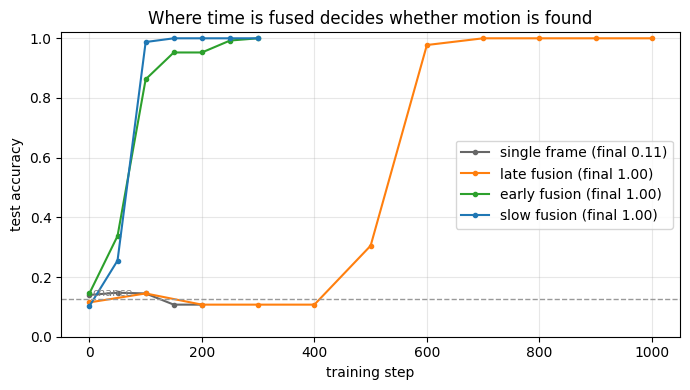

In [13]:
FUSION = ['single frame', 'late fusion', 'early fusion', 'slow fusion']
COLORS = {'single frame': '0.4', 'late fusion': 'tab:orange', 'early fusion': 'tab:green', 'slow fusion': 'tab:blue',
          '3D CNN': 'tab:red', 'temporal stream': 'tab:purple', 'LRCN': 'tab:brown'}

fig, ax = plt.subplots(figsize=(7, 4))
for name in FUSION:
    steps_, accs_ = zip(*results[name]['curve'])
    ax.plot(steps_, accs_, 'o-', ms=3, color=COLORS[name], label=f"{name} (final {results[name]['acc']:.2f})")
ax.axhline(1 / N_CLASSES, ls='--', color='0.6', lw=1); ax.text(5, 1 / N_CLASSES + 0.01, 'chance', color='0.5', fontsize=8)
ax.set_xlabel('training step'); ax.set_ylabel('test accuracy'); ax.set_ylim(0, 1.02)
ax.set_title('Where time is fused decides whether motion is found'); ax.legend(loc='center right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Widget 2: the fusion chooser

Pick a fusion strategy from the dropdown. The chosen curve is drawn in color over the others in gray, with its parameter count, training time and final accuracy. Nothing is retrained here: the curves were recorded above.

In [14]:
def fusion_chooser(strategy='slow fusion'):
    fig, ax = plt.subplots(figsize=(7, 3.8))
    for name in FUSION:
        steps_, accs_ = zip(*results[name]['curve'])
        if name == strategy:
            ax.plot(steps_, accs_, 'o-', ms=4, color=COLORS[name], lw=2, label=name)
        else:
            ax.plot(steps_, accs_, '-', color='0.8', lw=1)
    ax.axhline(1 / N_CLASSES, ls='--', color='0.6', lw=1)
    r = results[strategy]
    ax.set_title(f"{strategy}: {r['params']:,} parameters, trained in {r['seconds']:.1f} s, "
                 f"final test accuracy {r['acc']:.3f}")
    ax.set_xlabel('training step'); ax.set_ylabel('test accuracy'); ax.set_ylim(0, 1.02); ax.grid(alpha=0.3)
    ax.legend(loc='center right')
    plt.tight_layout(); plt.show()

interact(fusion_chooser, strategy=Dropdown(options=FUSION, value='slow fusion'));

interactive(children=(Dropdown(description='strategy', index=3, options=('single frame', 'late fusion', 'early…

## 4. 3D convolution

In a 2D convolution each output unit sees one frame. In a **3D convolution** the kernel has a temporal extent $k_T$ as well, so one output unit sees $k_T$ contiguous frames at once, and motion becomes something the filter itself can respond to. The slide's "time = another dimension" is literal: with input $x \in \mathbb{R}^{C \times T \times H \times W}$ and kernel $w \in \mathbb{R}^{C \times k_T \times k_H \times k_W}$,

$$y[t, i, j] = \sum_{c} \sum_{a=0}^{k_T - 1} \sum_{p=0}^{k_H - 1} \sum_{q=0}^{k_W - 1} w[c, a, p, q] \; x[c,\; t + a,\; i + p,\; j + q]$$

which is the 2D formula with one more index. Slow fusion in section 3 was already built from this operation; here it gets written out, checked and then used on its own.

### 4a. `conv3d` from scratch, verified against `F.conv3d`

The implementation below accumulates one kernel tap at a time: for each offset $(a, p, q)$ it takes the matching strided block of the padded input and adds its channel-mixed contribution to the output. That is exactly the sum above with the loops reordered. We check it on random tensors with several kernel shapes, strides and paddings, in float64.

In [15]:
def conv3d_scratch(x, w, b=None, stride=1, padding=0):
    """3D convolution (cross-correlation, as in PyTorch) written out.
    x: (N, Cin, T, H, W), w: (Cout, Cin, kT, kH, kW). Every output voxel is a dot product between the kernel
    and one kT x kH x kW block of the padded input; here the sum is accumulated one kernel tap at a time."""
    s, p = stride, padding
    x = F.pad(x, (p, p, p, p, p, p))                                  # pad W, H and T
    N, Cin, Tp, Hp, Wp = x.shape
    Cout, _, kT, kH, kW = w.shape
    To, Ho, Wo = (Tp - kT) // s + 1, (Hp - kH) // s + 1, (Wp - kW) // s + 1
    out = torch.zeros(N, Cout, To, Ho, Wo, dtype=x.dtype, device=x.device)
    for a in range(kT):
        for i in range(kH):
            for j in range(kW):
                block = x[:, :, a:a + s * To:s, i:i + s * Ho:s, j:j + s * Wo:s]      # (N, Cin, To, Ho, Wo)
                out += torch.einsum('nctuv,oc->notuv', block, w[:, :, a, i, j])
    if b is not None:
        out += b[None, :, None, None, None]
    return out

set_seed(0)
configs = [  # (N, Cin, Cout, T, H, W, (kT, kH, kW), stride, padding)
    (1, 1, 1, 5, 6, 6, (3, 3, 3), 1, 0), (2, 3, 4, 8, 9, 9, (3, 3, 3), 1, 1),
    (2, 2, 3, 7, 8, 8, (2, 3, 3), 2, 1), (1, 3, 2, 6, 7, 5, (1, 3, 3), 1, 0), (2, 2, 2, 9, 9, 9, (3, 5, 5), 3, 2)]
for (N, Cin, Cout, T3, H3, W3, k, s, p) in configs:
    x = torch.randn(N, Cin, T3, H3, W3, dtype=torch.float64)
    w = torch.randn(Cout, Cin, *k, dtype=torch.float64)
    b = torch.randn(Cout, dtype=torch.float64)
    mine = conv3d_scratch(x, w, b, stride=s, padding=p)
    ref = F.conv3d(x, w, b, stride=s, padding=p)
    assert mine.shape == ref.shape and torch.allclose(mine, ref, atol=1e-10), (k, s, p)
    print(f'kernel {k} stride {s} pad {p}: {tuple(x.shape)} -> {tuple(mine.shape)}   '
          f'max |diff| vs F.conv3d = {(mine - ref).abs().max():.1e}')
print('\nassert torch.allclose(conv3d_scratch, F.conv3d)   PASSED for all configurations')

kernel (3, 3, 3) stride 1 pad 0: (1, 1, 5, 6, 6) -> (1, 1, 3, 4, 4)   max |diff| vs F.conv3d = 3.6e-15
kernel (3, 3, 3) stride 1 pad 1: (2, 3, 8, 9, 9) -> (2, 4, 8, 9, 9)   max |diff| vs F.conv3d = 2.1e-14
kernel (2, 3, 3) stride 2 pad 1: (2, 2, 7, 8, 8) -> (2, 3, 4, 4, 4)   max |diff| vs F.conv3d = 1.2e-14
kernel (1, 3, 3) stride 1 pad 0: (1, 3, 6, 7, 5) -> (1, 2, 6, 5, 3)   max |diff| vs F.conv3d = 3.6e-15
kernel (3, 5, 5) stride 3 pad 2: (2, 2, 9, 9, 9) -> (2, 2, 4, 3, 3)   max |diff| vs F.conv3d = 2.0e-14

assert torch.allclose(conv3d_scratch, F.conv3d)   PASSED for all configurations


### 4b. The Ji et al. (2012) architecture, layer by layer

*Ji, Xu, Yang and Yu, 3D Convolutional Neural Networks for Human Action Recognition, IEEE TPAMI 2012* is the slide's worked example, and its numbers are worth reproducing because every one of them is a small piece of arithmetic. Starting from 7 input frames at $60 \times 40$:

| Stage | Operation | Output |
|---|---|---|
| input | 7 frames | `7@60x40` |
| H1 | hardwired | `33@60x40` |
| C2 | 7x7x3 3D convolution, 2 kernel sets | `23*2@54x34` |
| S3 | 2x2 subsampling | `23*2@27x17` |
| C4 | 7x6x3 3D convolution, 3 kernel sets | `13*6@21x12` |
| S5 | 3x3 subsampling | `13*6@7x4` |
| C6 | 7x4 convolution | feature vector |
| output | full connection | classes |

Two families of numbers appear. The **spatial** sizes follow the valid-convolution rule $\text{out} = \text{in} - k + 1$ and integer division for subsampling. The **channel** counts $23 \cdot 2$ and $13 \cdot 6$ come from the *temporal* side: the hardwired layer produces five groups of frames (gray, gradient-x, gradient-y, flow-x, flow-y) with 7, 7, 7, 6, 6 frames respectively; a temporal extent of 3 shrinks each group by 2; the maps of one kernel set are the frames that remain, summed over the five groups; and each new kernel set multiplies the number of sets.

In [16]:
# Spatial arithmetic. Valid convolution: out = in - k + 1; subsampling: out = in // k.
def conv_out(size, k): return size - k + 1
def pool_out(size, k): return size // k

h, w = 60, 40
steps = []
h, w = conv_out(h, 7), conv_out(w, 7);  steps.append(('C2  7x7x3 conv', h, w, (54, 34)))
h, w = pool_out(h, 2), pool_out(w, 2);  steps.append(('S3  2x2 pool  ', h, w, (27, 17)))
h, w = conv_out(h, 7), conv_out(w, 6);  steps.append(('C4  7x6x3 conv', h, w, (21, 12)))
h, w = pool_out(h, 3), pool_out(w, 3);  steps.append(('S5  3x3 pool  ', h, w, (7, 4)))
for name, hh, ww, expected in steps:
    ok = (hh, ww) == expected
    print(f'  {name}: {hh:3d} x {ww:3d}   slide says {expected[0]:3d} x {expected[1]:3d}   {"ok" if ok else "MISMATCH"}')
    assert ok, f'{name} disagrees with the slide'
assert conv_out(7, 7) == 1 and conv_out(4, 4) == 1
print('  C6  7x4 conv on a 7x4 map -> 1 x 1, i.e. a feature vector')

# Temporal arithmetic: where 33, 23*2 and 13*6 come from.
groups = {'gray': 7, 'gradient-x': 7, 'gradient-y': 7, 'flow-x': 6, 'flow-y': 6}
assert sum(groups.values()) == 33
after_c2 = {g: conv_out(n, 3) for g, n in groups.items()}          # temporal extent 3 removes 2 frames per group
after_c4 = {g: conv_out(n, 3) for g, n in after_c2.items()}
print(f'\n  H1 hardwired : {" + ".join(f"{n} {g}" for g, n in groups.items())} = {sum(groups.values())} maps')
print(f'  C2 extent 3  : {" + ".join(str(n) for n in after_c2.values())} = {sum(after_c2.values())} maps per kernel set, '
      f'2 sets -> {sum(after_c2.values())}*2 = {2 * sum(after_c2.values())}')
print(f'  C4 extent 3  : {" + ".join(str(n) for n in after_c4.values())} = {sum(after_c4.values())} maps per kernel set, '
      f'2 x 3 sets -> {sum(after_c4.values())}*6 = {6 * sum(after_c4.values())}')
assert sum(after_c2.values()) == 23 and sum(after_c4.values()) == 13

  C2  7x7x3 conv:  54 x  34   slide says  54 x  34   ok
  S3  2x2 pool  :  27 x  17   slide says  27 x  17   ok
  C4  7x6x3 conv:  21 x  12   slide says  21 x  12   ok
  S5  3x3 pool  :   7 x   4   slide says   7 x   4   ok
  C6  7x4 conv on a 7x4 map -> 1 x 1, i.e. a feature vector

  H1 hardwired : 7 gray + 7 gradient-x + 7 gradient-y + 6 flow-x + 6 flow-y = 33 maps
  C2 extent 3  : 5 + 5 + 5 + 4 + 4 = 23 maps per kernel set, 2 sets -> 23*2 = 46
  C4 extent 3  : 3 + 3 + 3 + 2 + 2 = 13 maps per kernel set, 2 x 3 sets -> 13*6 = 78


### 4c. The hardwired layer, built for real: gray, gradients and Lucas-Kanade flow

H1 is not learned. Ji et al. **hardwire** it to encode prior knowledge about what matters in a video: each of the 7 input frames becomes a gray-level map, an $x$-gradient map and a $y$-gradient map (that is $3 \times 7 = 21$ maps), and each of the 6 pairs of consecutive frames becomes an optical-flow field with $x$ and $y$ components ($2 \times 6 = 12$ maps). Total: 33.

Gradients are finite differences. Optical flow needs a real algorithm, and the classical one fits in a dozen lines. **Lucas-Kanade** (Lucas and Kanade, 1981) assumes brightness is conserved along the motion, $I(x + u, y + v, t + 1) = I(x, y, t)$, linearizes to the **brightness-constancy equation** $I_x u + I_y v + I_t = 0$, and solves for one $(u, v)$ per pixel by least squares over a small window (5x5 here), because a single pixel gives one equation for two unknowns:

$$\begin{pmatrix} \sum I_x^2 & \sum I_x I_y \\ \sum I_x I_y & \sum I_y^2 \end{pmatrix} \begin{pmatrix} u \\ v \end{pmatrix} = - \begin{pmatrix} \sum I_x I_t \\ \sum I_y I_t \end{pmatrix}$$

The window sums are box filters, so the whole thing is a few `conv2d` calls. Where the $2 \times 2$ matrix is nearly singular (flat regions, and straight edges where only the normal component of the flow is observable, the **aperture problem**) the flow is left at zero.

Because our motion is known exactly, the flow can be checked against ground truth: the median flow over the moving pixels of a "right, slow" clip should be close to $(u, v) = (1, 0)$.

In [17]:
def lucas_kanade(a, b, win=5):
    """Dense optical flow from gray frame a to gray frame b, both (N, S, S), by Lucas-Kanade.
    Solves I_x u + I_y v + I_t = 0 by least squares over a win x win window at every pixel.
    Returns flow (N, 2, S, S) with u along x (columns) and v along y (rows), and a mask of well-conditioned pixels."""
    a, b = a[:, None], b[:, None]
    kx = torch.tensor([[[[-0.5, 0.0, 0.5]]]], device=a.device)      # central differences
    ky = kx.transpose(2, 3)
    m = 0.5 * (a + b)                                                 # spatial gradients of the average frame
    Ix, Iy, It = F.conv2d(m, kx, padding=(0, 1)), F.conv2d(m, ky, padding=(1, 0)), b - a
    box = torch.ones(1, 1, win, win, device=a.device) / win ** 2
    sm = lambda z: F.conv2d(z, box, padding=win // 2)                  # window sums
    Sxx, Syy, Sxy, Sxt, Syt = sm(Ix * Ix), sm(Iy * Iy), sm(Ix * Iy), sm(Ix * It), sm(Iy * It)
    det = Sxx * Syy - Sxy ** 2
    ok = det > 1e-4                                                   # aperture problem / flat regions: skip
    u = torch.where(ok, (-Syy * Sxt + Sxy * Syt) / det.clamp(min=1e-8), torch.zeros_like(det))
    v = torch.where(ok, (Sxy * Sxt - Sxx * Syt) / det.clamp(min=1e-8), torch.zeros_like(det))
    return torch.cat([u, v], dim=1), ok[:, 0]

def hardwired_layer(frames):
    """Ji et al.'s H1 on 7 RGB frames (7, 3, S, S): 7 gray + 7 gradient-x + 7 gradient-y + 6 flow-x + 6 flow-y = 33 maps."""
    g = frames.mean(1)                                                # (7, S, S) gray
    kx = torch.tensor([[[[-0.5, 0.0, 0.5]]]], device=g.device)
    gx = F.conv2d(g[:, None], kx, padding=(0, 1))[:, 0]
    gy = F.conv2d(g[:, None], kx.transpose(2, 3), padding=(1, 0))[:, 0]
    flow, _ = lucas_kanade(g[:-1], g[1:])                             # (6, 2, S, S)
    return torch.cat([g, gx, gy, flow[:, 0], flow[:, 1]])

maps = hardwired_layer(Xte[0, :7])
assert maps.shape == (33, S, S)
print(f'hardwired layer: 7 frames {tuple(Xte[0, :7].shape)} -> {tuple(maps.shape)}   (33 maps, none of them learned)')

# Check the flow against the known motion: median flow over the moving pixels, frame 0 -> frame 1, every test clip.
gray = Xte.mean(2)
flow, ok = lucas_kanade(gray[:, 0], gray[:, 1])
moving = (gray[:, 1] - gray[:, 0]).abs() > 0.15
true_uv = torch.tensor([[DIRECTIONS[DIR_NAMES[int(d)]][1] * SPEEDS[int(v)],
                         DIRECTIONS[DIR_NAMES[int(d)]][0] * SPEEDS[int(v)]] for d, v in zip(dir_te, spd_te)],
                       dtype=torch.float32, device=device)                                   # (N, 2) as (u, v)
est_uv = torch.zeros_like(true_uv)
for i in range(len(Xte)):
    sel = ok[i] & moving[i]
    if sel.sum() > 3:
        est_uv[i] = torch.stack([flow[i, 0][sel].median(), flow[i, 1][sel].median()])
dominant = true_uv.abs().argmax(1)                                                  # which component moves
sign_ok = (torch.sign(est_uv.gather(1, dominant[:, None])) == torch.sign(true_uv.gather(1, dominant[:, None]))).float().mean()
print(f'\nsign of the dominant flow component correct on {100 * sign_ok:.1f}% of test clips')
for v_i, v in enumerate(SPEEDS):
    sel = spd_te == v_i
    mag = est_uv[sel].gather(1, dominant[sel][:, None]).abs().mean()
    cross = est_uv[sel].gather(1, 1 - dominant[sel][:, None]).abs().mean()
    print(f'  true speed {v} px/frame: estimated |flow| along the motion {mag:.2f}, across it {cross:.2f}')
assert sign_ok > 0.9
print('\n1-pixel motion is recovered to within a few tenths of a pixel; 3-pixel motion is underestimated because')
print('Lucas-Kanade linearizes brightness constancy, which assumes small displacements (pyramids fix this)')

hardwired layer: 7 frames (7, 3, 32, 32) -> (33, 32, 32)   (33 maps, none of them learned)

sign of the dominant flow component correct on 98.0% of test clips
  true speed 1 px/frame: estimated |flow| along the motion 1.27, across it 0.03
  true speed 3 px/frame: estimated |flow| along the motion 1.93, across it 0.05

1-pixel motion is recovered to within a few tenths of a pixel; 3-pixel motion is underestimated because
Lucas-Kanade linearizes brightness constancy, which assumes small displacements (pyramids fix this)


The 33 maps for one clip, as five rows. The gradient rows outline the shape, the flow rows are nonzero only on the moving edges that are well conditioned (the corners of a square, the whole rim of a disc), and their sign gives the direction: for this clip the $u$ row is uniformly one sign and the $v$ row is essentially empty, or the other way round.

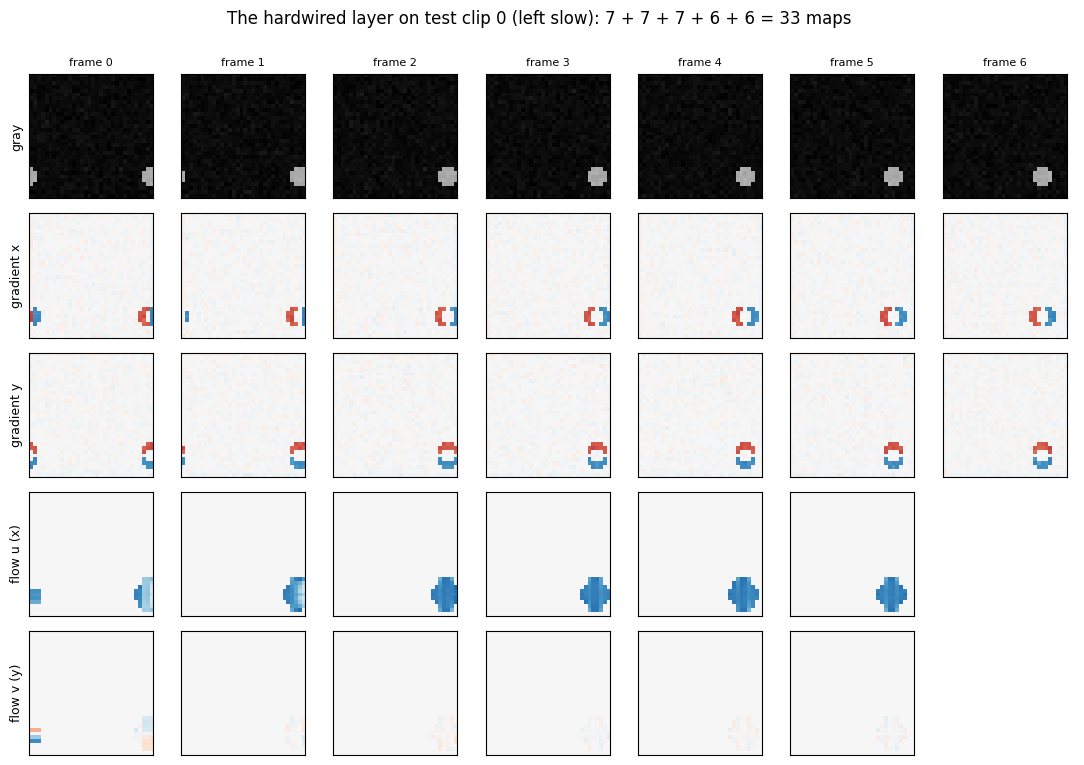

In [18]:
fig, axes = plt.subplots(5, 7, figsize=(11, 7.6))
rows = [('gray', maps[0:7], 'gray', 0, 1), ('gradient x', maps[7:14], 'RdBu_r', -0.5, 0.5),
        ('gradient y', maps[14:21], 'RdBu_r', -0.5, 0.5), ('flow u (x)', maps[21:27], 'RdBu_r', -2, 2),
        ('flow v (y)', maps[27:33], 'RdBu_r', -2, 2)]
for r, (name, block, cmap, lo, hi) in enumerate(rows):
    for c in range(7):
        ax = axes[r, c]
        ax.set_xticks([]); ax.set_yticks([])
        if c < block.shape[0]:
            ax.imshow(block[c].detach().cpu().numpy(), cmap=cmap, vmin=lo, vmax=hi)
        else:
            ax.axis('off')
    axes[r, 0].set_ylabel(name, fontsize=9)
for c in range(7):
    axes[0, c].set_title(f'frame {c}', fontsize=8)
plt.suptitle(f'The hardwired layer on test clip 0 ({CLASS_NAMES[int(yte[0])]}): 7 + 7 + 7 + 6 + 6 = 33 maps', y=1.0)
plt.tight_layout(); plt.show()

### 4d. What a temporal extent costs

A 3D kernel with temporal extent $k_T$ has $k_T$ times the weights of the 2D kernel with the same spatial size: $7 \times 7 \times 3 = 147$ against $7 \times 7 = 49$ for the slide's kernels. It also consumes the clip: a valid 3D convolution with extent $k_T$ returns $T - k_T + 1$ frames, so with extent 3 at every layer a 16-frame clip supports at most 7 layers before the time axis is gone (padding in time, or pooling instead of striding, are the usual escapes).

  2D 3x3 kernel   :   4608 weights
  3D 3x3x3 kernel :  13824 weights   (3x, the temporal extent)

  slide kernels: 7x7 = 49 weights vs 7x7x3 = 147 weights per (in, out) pair, a factor of 3


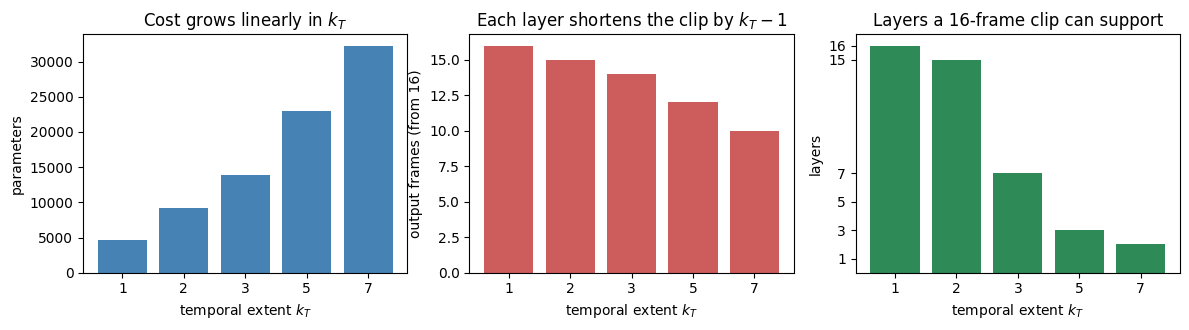

In [19]:
# 3D convolution costs a factor of k more parameters than 2D, for temporal extent k.
Cin, Cout, k = 16, 32, 3
p2d = count_params(nn.Conv2d(Cin, Cout, k, bias=False))
p3d = count_params(nn.Conv3d(Cin, Cout, k, bias=False))
assert p3d == k * p2d, 'the 3D/2D ratio is not the temporal extent'
print(f'  2D {k}x{k} kernel   : {p2d:6d} weights')
print(f'  3D {k}x{k}x{k} kernel : {p3d:6d} weights   ({p3d // p2d}x, the temporal extent)')
print(f'\n  slide kernels: 7x7 = {7 * 7} weights vs 7x7x3 = {7 * 7 * 3} weights per (in, out) pair, '
      f'a factor of {7 * 7 * 3 // (7 * 7)}')

# Static sweep: how temporal extent trades receptive field against cost.
extents = [1, 2, 3, 5, 7]
params, out_T, depth = [], [], []
for k in extents:
    c = nn.Conv3d(16, 32, kernel_size=(k, 3, 3), bias=False)
    params.append(count_params(c))
    out_T.append(c(torch.randn(1, 16, 16, 8, 8)).shape[2])
    depth.append(15 // (k - 1) if k > 1 else 16)
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
ax[0].bar([str(k) for k in extents], params, color='steelblue')
ax[0].set_xlabel('temporal extent $k_T$'); ax[0].set_ylabel('parameters'); ax[0].set_title('Cost grows linearly in $k_T$')
ax[1].bar([str(k) for k in extents], out_T, color='indianred')
ax[1].set_xlabel('temporal extent $k_T$'); ax[1].set_ylabel('output frames (from 16)'); ax[1].set_title('Each layer shortens the clip by $k_T - 1$')
ax[2].bar([str(k) for k in extents], depth, color='seagreen')
ax[2].set_xlabel('temporal extent $k_T$'); ax[2].set_ylabel('layers'); ax[2].set_title('Layers a 16-frame clip can support')
ax[2].set_yticks([1, 3, 5, 7, 15, 16])
plt.tight_layout(); plt.show()

### Widget 3: temporal extent versus cost

Drag `k_T` and read off the parameter count, the number of frames left after one valid layer, and how many such layers a 16-frame clip can support. Change the channel counts to see that the factor $k_T$ does not depend on them.

In [20]:
def extent_explorer(k_T=3, in_ch=16, out_ch=32, clip_len=16):
    c3 = nn.Conv3d(in_ch, out_ch, (k_T, 3, 3), bias=False)
    c2 = nn.Conv2d(in_ch, out_ch, 3, bias=False)
    p3, p2 = count_params(c3), count_params(c2)
    out_len = clip_len - k_T + 1
    layers = (clip_len - 1) // (k_T - 1) if k_T > 1 else clip_len
    print(f'3D kernel ({k_T}, 3, 3): {p3:,} weights = {p3 // p2} x the 2D 3x3 kernel ({p2:,})')
    print(f'one valid layer: {clip_len} frames -> {out_len} frames;  '
          f'{layers if k_T > 1 else "any number of"} such layers fit in a {clip_len}-frame clip')
    fig, ax = plt.subplots(1, 2, figsize=(8, 3.2))
    ax[0].bar(['2D 3x3', f'3D {k_T}x3x3'], [p2, p3], color=['0.6', 'steelblue'])
    ax[0].set_ylabel('parameters'); ax[0].set_title(f'{p3 // p2}x the weights')
    lens = [clip_len]
    while lens[-1] - (k_T - 1) >= 1 and len(lens) < 20 and k_T > 1:
        lens.append(lens[-1] - (k_T - 1))
    ax[1].plot(range(len(lens)), lens, 'o-', color='indianred')
    ax[1].set_xlabel('layers of extent $k_T$'); ax[1].set_ylabel('frames remaining'); ax[1].set_ylim(0, clip_len + 1)
    ax[1].set_title('the clip runs out'); ax[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

interact(extent_explorer, k_T=IntSlider(min=1, max=7, step=1, value=3),
                          in_ch=IntSlider(min=8, max=64, step=8, value=16),
                          out_ch=IntSlider(min=8, max=64, step=8, value=32),
                          clip_len=IntSlider(min=8, max=32, step=8, value=16));

interactive(children=(IntSlider(value=3, description='k_T', max=7, min=1), IntSlider(value=16, description='in…

### 4e. A tiny 3D CNN, trained

The network below is the modern shape of the idea (Tran et al.'s C3D, ICCV 2015, uses $3 \times 3 \times 3$ kernels everywhere): three 3D convolutions with $3 \times 3 \times 3$ kernels and "same" padding, so nothing is lost in time, pooling first over space only and then over space and time, and global average pooling into the classifier. With only 8 channels in its first layer it has fewer parameters than any of the 2D models, because it never flattens a spatial map into a fully connected layer.

In [21]:
class Conv3DNet(nn.Module):
    """A small C3D-style network: 3x3x3 kernels, pooling over space and then over space and time."""
    def __init__(self, w=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(3, w, 3, stride=(1, 2, 2), padding=1), nn.ReLU(), nn.MaxPool3d((1, 2, 2)),   # T 8, 32 -> 8
            nn.Conv3d(w, 2 * w, 3, padding=1), nn.ReLU(), nn.MaxPool3d(2),                       # T 8 -> 4, 8 -> 4
            nn.Conv3d(2 * w, 4 * w, 3, padding=1), nn.ReLU(),                                    # T 4, 4 x 4
            nn.AdaptiveAvgPool3d(1), nn.Flatten())
        self.head = nn.Linear(4 * w, N_CLASSES)
    def forward(self, x):                                 # (N, T, C, H, W) -> (N, C, T, H, W)
        return self.head(self.net(x.transpose(1, 2)))

print('3D CNN')
set_seed(0)
models['3D CNN'] = Conv3DNet()
results['3D CNN'] = train_model(models['3D CNN'], steps=300)
print(f"\n{results['3D CNN']['params']:,} parameters, {results['3D CNN']['seconds']:.1f} s, "
      f"test accuracy {results['3D CNN']['acc']:.3f}")

3D CNN
  step    0   train loss   nan   test acc 0.145   ( 0.0s)


  step   50   train loss 1.743   test acc 0.775   ( 0.9s)


  step  100   train loss 0.312   test acc 0.993   ( 1.7s)


  step  150   train loss 0.043   test acc 1.000   ( 2.6s)


  step  200   train loss 0.019   test acc 1.000   ( 3.4s)


  step  250   train loss 0.010   test acc 1.000   ( 4.3s)


  step  300   train loss 0.007   test acc 1.000   ( 5.1s)

18,248 parameters, 5.1 s, test accuracy 1.000


The first-layer filters of the trained 3D CNN, averaged over color, shown as their three temporal slices. A filter whose slices are identical would be a 2D filter in disguise; the learned ones differ from slice to slice, and several look like a bright blob at one position followed by a dark blob nearby, which is a motion detector.

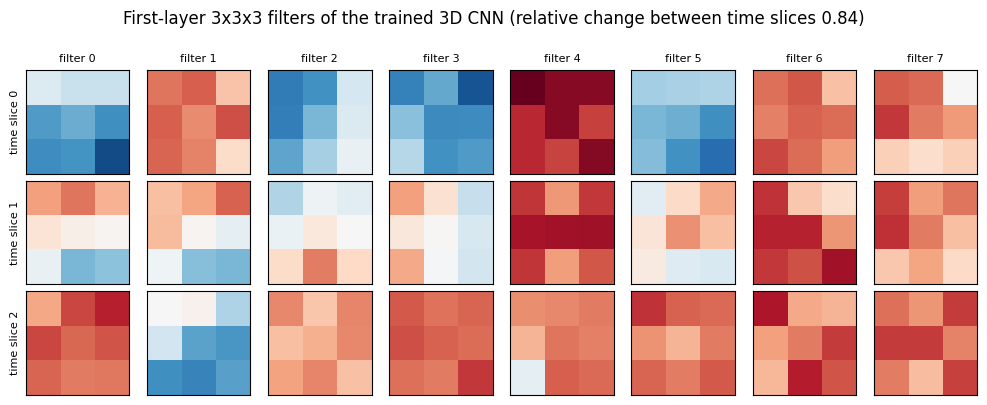

In [22]:
w1 = models['3D CNN'].net[0].weight.detach().cpu().mean(1)          # (8 filters, 3 time, 3, 3)
fig, axes = plt.subplots(3, 8, figsize=(10, 4))
vmax = w1.abs().max().item()
for f in range(8):
    for a in range(3):
        ax = axes[a, f]
        ax.imshow(w1[f, a].numpy(), cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.set_xticks([]); ax.set_yticks([])
    axes[0, f].set_title(f'filter {f}', fontsize=8)
for a in range(3):
    axes[a, 0].set_ylabel(f'time slice {a}', fontsize=8)
slice_change = (w1[:, 1:] - w1[:, :-1]).abs().mean() / w1.abs().mean()
plt.suptitle(f'First-layer 3x3x3 filters of the trained 3D CNN (relative change between time slices {slice_change:.2f})', y=1.0)
plt.tight_layout(); plt.show()

## 5. The two-stream network

*Simonyan and Zisserman, Two-Stream Convolutional Networks for Action Recognition in Videos, NeurIPS 2014* take the other branch of the taxonomy: keep 2D convolutions, and hand the temporal information to a second network explicitly.

- The **spatial stream** sees a single RGB frame: appearance.
- The **temporal stream** sees a stack of **optical flow** fields: motion. Flow between two frames decomposes into a horizontal and a vertical component, so $L$ stacked flow frames give $2L$ input channels.
- The two softmax outputs are combined by **class score fusion**, in the simplest case by averaging.

The layer specifications printed on the slides are identical for both streams, `7x7x96 stride 2` then `5x5x256 stride 2` then three `3x3x512` then `4096` then `2048` then softmax, with exactly one difference: the spatial stream normalizes after conv2 and the temporal stream does not. The only thing that changes at the input is the channel count, as the shapes below show.

In [23]:
# Build both stream inputs at the paper's scale, and the fusion step.
L_flow = 10                                              # number of stacked flow frames
spatial_in = torch.randn(1, 3, 224, 224)                 # one RGB frame
temporal_in = torch.randn(1, 2 * L_flow, 224, 224)       # L flow fields, 2 components each
print(f'  spatial stream input : {tuple(spatial_in.shape)}   (3 channels: RGB)')
print(f'  temporal stream input: {tuple(temporal_in.shape)}  (2 x {L_flow} = {2 * L_flow} channels: '
      f'horizontal + vertical flow)')

conv1_spatial = nn.Conv2d(3, 96, kernel_size=7, stride=2)
conv1_temporal = nn.Conv2d(2 * L_flow, 96, kernel_size=7, stride=2)
print(f'\n  both conv1 layers produce {tuple(conv1_spatial(spatial_in).shape)} and '
      f'{tuple(conv1_temporal(temporal_in).shape)}')
print('  same 7x7x96 stride-2 spec; only the input channel count differs')

# Class score fusion: average the two softmax outputs.
n_classes = 101
s_scores = torch.softmax(torch.randn(1, n_classes), dim=1)
t_scores = torch.softmax(torch.randn(1, n_classes), dim=1)
fused = (s_scores + t_scores) / 2
assert abs(fused.sum().item() - 1.0) < 1e-5
print(f'\n  class score fusion: {tuple(s_scores.shape)} + {tuple(t_scores.shape)} -> '
      f'{tuple(fused.shape)}, sums to {fused.sum():.4f}')

  spatial stream input : (1, 3, 224, 224)   (3 channels: RGB)
  temporal stream input: (1, 20, 224, 224)  (2 x 10 = 20 channels: horizontal + vertical flow)

  both conv1 layers produce (1, 96, 109, 109) and (1, 96, 109, 109)
  same 7x7x96 stride-2 spec; only the input channel count differs

  class score fusion: (1, 101) + (1, 101) -> (1, 101), sums to 1.0000


### 5a. A two-stream network on our clips

The **spatial stream** is the single-frame model of section 1, already trained (and already known to be at chance, by design). The **temporal stream** gets $L$ consecutive **frame differences** $d_t = \bar x_{t+1} - \bar x_t$ of the gray frames, stacked as $L$ channels. This is a stand-in for optical flow: a difference frame is the temporal derivative $I_t$ of the brightness-constancy equation, one channel per frame pair instead of the two flow components, and a lot cheaper than running Lucas-Kanade on every clip. (Exercise 3 swaps in the real flow from section 4c, with $2L$ channels.)

The paper stacks $L = 10$ flow fields. Our clips have 7 differences, so we train the temporal stream for $L \in \{1, 2, 4, 7\}$ and record how much each extra difference frame buys.

In [24]:
def difference_stack(x, L):
    """Temporal-stream input: the first L consecutive gray-frame differences of each clip, as L channels."""
    g = x.mean(2)                                        # (N, T, S, S) gray
    return (g[:, 1:] - g[:, :-1])[:, :L]                 # (N, L, S, S)

class TemporalStream(nn.Module):
    """The same tower as the spatial stream, on L stacked difference frames instead of one RGB frame."""
    def __init__(self, L):
        super().__init__()
        self.L = L
        self.cnn = FrameCNN(L)
        self.head = head(self.cnn.out_dim)
    def forward(self, x):
        return self.head(self.cnn(difference_stack(x, self.L)))

L_VALUES = [1, 2, 4, 7]
for L in L_VALUES:
    print(f'temporal stream, L = {L} stacked difference frames')
    set_seed(0)
    models[f'temporal L={L}'] = TemporalStream(L)
    results[f'temporal L={L}'] = train_model(models[f'temporal L={L}'], steps=300, log_every=100)
    print(f"  -> {results[f'temporal L={L}']['params']:,} parameters, test accuracy {results[f'temporal L={L}']['acc']:.3f}\n")

temporal stream, L = 1 stacked difference frames
  step    0   train loss   nan   test acc 0.132   ( 0.0s)


  step  100   train loss 1.785   test acc 0.260   ( 0.5s)


  step  200   train loss 1.225   test acc 0.775   ( 1.0s)


  step  300   train loss 0.217   test acc 0.988   ( 1.5s)
  -> 89,416 parameters, test accuracy 0.988

temporal stream, L = 2 stacked difference frames
  step    0   train loss   nan   test acc 0.145   ( 0.0s)


  step  100   train loss 1.598   test acc 0.545   ( 0.5s)


...

  step  200   train loss 0.463   test acc 0.935   ( 1.1s)


  step  300   train loss 0.146   test acc 0.990   ( 1.6s)
  -> 89,848 parameters, test accuracy 0.990

temporal stream, L = 7 stacked difference frames
  step    0   train loss   nan   test acc 0.112   ( 0.0s)


  step  100   train loss 1.458   test acc 0.632   ( 0.6s)


  step  200   train loss 0.459   test acc 0.822   ( 1.2s)


  step  300   train loss 0.165   test acc 0.980   ( 1.7s)
  -> 90,280 parameters, test accuracy 0.980



### The stacked differences, and what $L$ buys

Left: the seven difference frames of one test clip. Each is a signed pair of blobs, the shape's old position in blue and its new position in red, so a single difference already contains the direction and, from the gap between the blobs, the speed. Right: the learning curves for the four values of $L$. More frames give a longer stretch of the trajectory to average over, which mainly helps early in training.

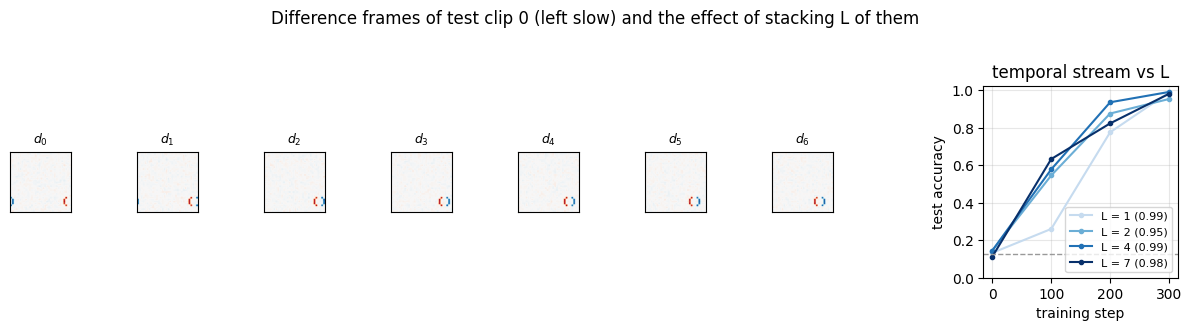

In [25]:
diffs = difference_stack(Xte[:1], 7)[0].detach().cpu()
fig = plt.figure(figsize=(12, 3.2))
gs = fig.add_gridspec(1, 9, width_ratios=[1] * 7 + [0.3, 3.2])
for t in range(7):
    ax = fig.add_subplot(gs[0, t])
    ax.imshow(diffs[t].numpy(), cmap='RdBu_r', vmin=-0.8, vmax=0.8)
    ax.set_title(f'$d_{t}$', fontsize=9); ax.set_xticks([]); ax.set_yticks([])
ax = fig.add_subplot(gs[0, 8])
for L, col in zip(L_VALUES, ['#c6dbef', '#6baed6', '#2171b5', '#08306b']):
    steps_, accs_ = zip(*results[f'temporal L={L}']['curve'])
    ax.plot(steps_, accs_, 'o-', ms=3, color=col, label=f"L = {L} ({results[f'temporal L={L}']['acc']:.2f})")
ax.axhline(1 / N_CLASSES, ls='--', color='0.6', lw=1)
ax.set_xlabel('training step'); ax.set_ylabel('test accuracy'); ax.set_ylim(0, 1.02); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title('temporal stream vs L')
plt.suptitle(f'Difference frames of test clip 0 ({CLASS_NAMES[int(yte[0])]}) and the effect of stacking L of them', y=1.02)
plt.tight_layout(); plt.show()

### Widget 4: how many difference frames?

Drag `L`. The panel shows the $L$ difference frames the temporal stream is given for one clip, and the corresponding recorded learning curve. Even $L = 1$ works on this data, because one difference frame already shows both positions; on real video, where flow is noisy and motion spans many frames, the paper found stacking essential.

In [26]:
def L_explorer(L=4, clip=0):
    L = min(L_VALUES, key=lambda v: abs(v - L))                      # snap to a trained value
    d = difference_stack(Xte[clip:clip + 1], 7)[0].detach().cpu()
    fig = plt.figure(figsize=(11, 2.9))
    gs = fig.add_gridspec(1, 9, width_ratios=[1] * 7 + [0.3, 3.0])
    for t in range(7):
        ax = fig.add_subplot(gs[0, t])
        if t < L:
            ax.imshow(d[t].numpy(), cmap='RdBu_r', vmin=-0.8, vmax=0.8)
        else:
            ax.imshow(torch.zeros(S, S).numpy(), cmap='gray', vmin=-1, vmax=1)
        ax.set_title(f'$d_{t}$' + ('' if t < L else ' (unused)'), fontsize=8); ax.set_xticks([]); ax.set_yticks([])
    ax = fig.add_subplot(gs[0, 8])
    for v in L_VALUES:
        steps_, accs_ = zip(*results[f'temporal L={v}']['curve'])
        ax.plot(steps_, accs_, 'o-' if v == L else '-', ms=3, color='tab:purple' if v == L else '0.8', lw=2 if v == L else 1)
    ax.axhline(1 / N_CLASSES, ls='--', color='0.6', lw=1)
    ax.set_ylim(0, 1.02); ax.set_xlabel('training step'); ax.set_ylabel('test accuracy'); ax.grid(alpha=0.3)
    ax.set_title(f"L = {L}: final accuracy {results[f'temporal L={L}']['acc']:.3f}")
    plt.suptitle(f'clip {clip}: {CLASS_NAMES[int(yte[clip])]}', y=1.03)
    plt.tight_layout(); plt.show()

interact(L_explorer, L=IntSlider(min=1, max=7, step=1, value=4, continuous_update=False),
                     clip=IntSlider(min=0, max=15, step=1, value=0, continuous_update=False));

interactive(children=(IntSlider(value=4, continuous_update=False, description='L', max=7, min=1), IntSlider(va…

### 5b. Class score fusion, measured

The two streams are combined by averaging their softmax outputs, $p = \tfrac12 (p_{\text{spatial}} + p_{\text{temporal}})$. On UCF101 the paper's spatial stream alone was already strong (appearance is informative there) and fusion added several points on top of the temporal stream. On our data the spatial stream is at chance by construction, so fusion can at best match the temporal stream: an uninformative stream contributes a nearly uniform distribution, which rarely changes the argmax. Sweeping the fusion weight $\alpha$ on the spatial stream makes the point: nothing happens until the temporal stream is nearly switched off.

In [27]:
class TwoStream(nn.Module):
    """Class score fusion: the average of the two streams' softmax outputs (a probability vector, not logits)."""
    def __init__(self, spatial, temporal, alpha=0.5):
        super().__init__()
        self.spatial, self.temporal, self.alpha = spatial, temporal, alpha
    def forward(self, x):
        return self.alpha * F.softmax(self.spatial(x), 1) + (1 - self.alpha) * F.softmax(self.temporal(x), 1)

models['two-stream'] = TwoStream(models['single frame'], models['temporal L=7']).to(device)
fused_scores = predict(models['two-stream'], Xte)
assert torch.allclose(fused_scores.sum(1), torch.ones(len(Xte), device=device), atol=1e-5)
results['two-stream'] = dict(acc=(fused_scores.argmax(1) == yte).float().mean().item(),
                             params=results['single frame']['params'] + results['temporal L=7']['params'],
                             seconds=results['single frame']['seconds'] + results['temporal L=7']['seconds'], curve=None)
print(f"spatial stream alone   : {results['single frame']['acc']:.3f}")
print(f"temporal stream alone  : {results['temporal L=7']['acc']:.3f}")
print(f"fused (average scores) : {results['two-stream']['acc']:.3f}   (scores sum to 1: verified)")

print('\nfusion weight alpha on the spatial stream:')
for alpha in [0.0, 0.25, 0.5, 0.75, 0.9, 1.0]:
    acc = accuracy(TwoStream(models['single frame'], models['temporal L=7'], alpha).to(device), Xte, yte)
    print(f'  alpha = {alpha:.2f}   accuracy {acc:.3f}')

spatial stream alone   : 0.108
temporal stream alone  : 0.980
fused (average scores) : 0.980   (scores sum to 1: verified)

fusion weight alpha on the spatial stream:
  alpha = 0.00   accuracy 0.980
  alpha = 0.25   accuracy 0.980
  alpha = 0.50   accuracy 0.980
  alpha = 0.75   accuracy 0.980
  alpha = 0.90   accuracy 0.978
  alpha = 1.00   accuracy 0.108


## 6. CNN + LSTM: LRCN

*Donahue et al., Long-term Recurrent Convolutional Networks for Visual Recognition and Description, CVPR 2015* take the RNN branch of the taxonomy. Each frame goes through a **CNN** whose weights are shared across time, producing one feature vector per frame; the vectors form a sequence that is fed to an **LSTM** (a single layer of 256 units in the paper's activity-recognition model); and a prediction is emitted at **every timestep**, not only at the last one. For activity recognition the paper averages the per-timestep predictions of a clip. As a shape trace:

$$(N, T, C, H, W) \;\to\; (N \cdot T, C, H, W) \;\xrightarrow{\text{CNN}}\; (N, T, D) \;\xrightarrow{\text{LSTM}}\; (N, T, \text{classes})$$

The CNN here is `FrameCNN` again, and the LSTM has 64 units instead of 256 to keep the run short. Because the CNN is applied per frame, the model accepts a clip of *any* length, and its parameter count does not depend on $T$.

In [28]:
class LRCN(nn.Module):
    """A CNN shared across time gives one feature vector per frame; an LSTM reads the sequence;
    a linear layer emits class scores at every timestep (Donahue et al., 2015)."""
    def __init__(self, hidden=64):
        super().__init__()
        self.cnn = FrameCNN(3)
        self.lstm = nn.LSTM(self.cnn.out_dim, hidden, batch_first=True)
        self.head = nn.Linear(hidden, N_CLASSES)
    def forward(self, x, all_steps=False):                 # x: (N, T, C, H, W)
        N, T_, C, H, W = x.shape
        feats = self.cnn(x.reshape(N * T_, C, H, W)).reshape(N, T_, -1)    # fold time into the batch, unfold
        seq, _ = self.lstm(feats)
        out = self.head(seq)                                               # (N, T, classes): one per timestep
        return out if all_steps else out[:, -1]

set_seed(0)
lrcn_demo = LRCN()
for T_demo in (4, 8, 16):
    clip = torch.randn(2, T_demo, 3, S, S)
    with torch.no_grad():
        flat = clip.reshape(2 * T_demo, 3, S, S)
        feats = lrcn_demo.cnn(flat).reshape(2, T_demo, -1)
        out = lrcn_demo(clip, all_steps=True)
    assert out.shape == (2, T_demo, N_CLASSES)
    print(f'T = {T_demo:2d}: video {str(tuple(clip.shape)):20s} folded {str(tuple(flat.shape)):16s} '
          f'CNN out {str(tuple(feats.shape)):14s} logits {tuple(out.shape)}')
print(f'\n{count_params(lrcn_demo):,} parameters, the same for every T: '
      f'{count_params(lrcn_demo.cnn):,} in the shared CNN, {count_params(lrcn_demo.lstm):,} in the LSTM, '
      f'{count_params(lrcn_demo.head):,} in the head')

T =  4: video (2, 4, 3, 32, 32)    folded (8, 3, 32, 32)   CNN out (2, 4, 1024)   logits (2, 4, 8)
T =  8: video (2, 8, 3, 32, 32)    folded (16, 3, 32, 32)  CNN out (2, 8, 1024)   logits (2, 8, 8)
T = 16: video (2, 16, 3, 32, 32)   folded (32, 3, 32, 32)  CNN out (2, 16, 1024)  logits (2, 16, 8)

303,144 parameters, the same for every T: 23,584 in the shared CNN, 279,040 in the LSTM, 520 in the head


### 6a. With the single-frame model's budget, the LRCN sits on a plateau

Train it exactly like the other models, with the default learning rate and the 200-step budget the single-frame model got, and with the per-timestep loss the paper uses (the cross-entropy is averaged over all eight predictions of a clip). Nothing happens: the printed training loss stays at $\ln 8 \approx 2.079$, the loss of a uniform guess, and the accuracy at chance. This is not a bug, and it is worth understanding. Every model that learned quickly in this notebook detects motion **locally**: a filter with temporal extent, or a filter over stacked differences, is a small pattern that fires wherever a shape moves, and gradient descent finds small patterns fast. The LRCN asks something harder of the LSTM: to compare two *global* 1024-dimensional descriptions of consecutive frames, produced by a randomly initialized CNN, and to work out from their difference where something moved. At initialization the gradient of that comparison carries little signal, so the model sits on a plateau, exactly as late fusion did in section 3. The question is only how long the plateau lasts.

In [29]:
print('LRCN from scratch, 200 steps at the default learning rate (per-timestep loss)')
set_seed(0)
lrcn_short = LRCN()
res_short = train_model(lrcn_short, steps=200, per_timestep=True)
print(f"\ntest accuracy {res_short['acc']:.3f}: chance is {1 / N_CLASSES:.3f}, and ln(8) = {math.log(8):.3f} is the loss of a uniform guess")
print(f"final logged training loss {res_short['losses'][-1][1]:.3f}: the model is still guessing uniformly")

LRCN from scratch, 200 steps at the default learning rate (per-timestep loss)
  step    0   train loss   nan   test acc 0.145   ( 0.0s)


  step   50   train loss 2.080   test acc 0.138   ( 1.1s)


  step  100   train loss 2.081   test acc 0.135   ( 2.2s)


  step  150   train loss 2.080   test acc 0.138   ( 3.3s)


  step  200   train loss 2.080   test acc 0.117   ( 4.3s)

test accuracy 0.117: chance is 0.125, and ln(8) = 2.079 is the loss of a uniform guess
final logged training loss 2.080: the model is still guessing uniformly


### 6b. With a longer budget, it learns

Donahue et al. never face this plateau, because they never train the CNN from scratch: it is CaffeNet, pretrained on ImageNet, and the LSTM is trained on top of features that already describe a frame. On our data there is no appearance to pretrain on, so the only remedy is patience. The run below is the *same* model, the same seed and the same learning rate as 6a, trained for 600 steps instead of 200; the first three log lines therefore repeat 6a exactly. Watch the loss column: it sits at $2.08$ for about 200 steps, then falls, and the accuracy follows it up to 100%. Two things about the loss are worth reading off. It is averaged over all eight timesteps, and the prediction at $t = 0$ has seen a single frame and can never beat a uniform guess, so the per-timestep loss has a floor of $\ln 8 / 8 \approx 0.26$ even for a perfect model. And the plateau is not a property of the architecture but of the budget: the LRCN is slower to leave chance than the local-motion models, not unable to.

LRCN from scratch, 600 steps at the default learning rate (per-timestep loss)
  step    0   train loss   nan   test acc 0.145   ( 0.0s)


  step  100   train loss 2.080   test acc 0.135   ( 2.1s)


  step  200   train loss 2.080   test acc 0.117   ( 4.3s)


  step  300   train loss 1.569   test acc 0.652   ( 6.4s)


  step  400   train loss 0.754   test acc 0.980   ( 8.5s)


  step  500   train loss 0.514   test acc 1.000   (10.5s)


  step  600   train loss 0.429   test acc 1.000   (12.6s)

303,144 parameters, 12.6 s, test accuracy (prediction at the last timestep) 1.000
the per-timestep loss cannot go below ln(8) / 8 = 0.260, because the prediction at t = 0 has seen one frame


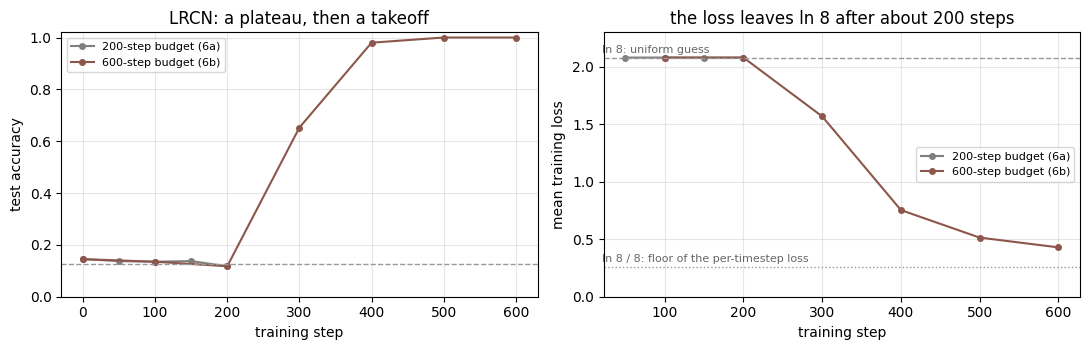


accuracy of the prediction made after seeing frames 0..t:
  t   =     0      1      2      3      4      5      6      7
  acc = 0.108  0.928  0.998  1.000  1.000  1.000  1.000  1.000
  averaging the per-timestep softmax over the clip (the paper's rule): 1.000
after one frame the LSTM can only guess (chance is 0.125); the prediction first passes 50% at t = 1, after 2 frames


In [30]:
print('LRCN from scratch, 600 steps at the default learning rate (per-timestep loss)')
set_seed(0)
models['LRCN'] = LRCN()
results['LRCN'] = train_model(models['LRCN'], steps=600, per_timestep=True, log_every=100)
print(f"\n{results['LRCN']['params']:,} parameters, {results['LRCN']['seconds']:.1f} s, "
      f"test accuracy (prediction at the last timestep) {results['LRCN']['acc']:.3f}")
print(f"the per-timestep loss cannot go below ln(8) / 8 = {math.log(8) / 8:.3f}, because the prediction at t = 0 has seen one frame")

# The two budgets side by side: accuracy and training loss.
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for res, lab, col in [(res_short, '200-step budget (6a)', 'tab:gray'), (results['LRCN'], '600-step budget (6b)', COLORS['LRCN'])]:
    ax[0].plot(*zip(*res['curve']), 'o-', ms=4, color=col, label=lab)
    st, lo = zip(*[(a, b) for a, b in res['losses'] if not math.isnan(b)])
    ax[1].plot(st, lo, 'o-', ms=4, color=col, label=lab)
ax[0].axhline(1 / N_CLASSES, ls='--', color='0.6', lw=1); ax[0].set_ylim(0, 1.02)
ax[0].set_xlabel('training step'); ax[0].set_ylabel('test accuracy'); ax[0].set_title('LRCN: a plateau, then a takeoff')
ax[1].axhline(math.log(8), ls='--', color='0.6', lw=1); ax[1].text(20, math.log(8) + 0.04, 'ln 8: uniform guess', fontsize=8, color='0.4')
ax[1].axhline(math.log(8) / 8, ls=':', color='0.6', lw=1); ax[1].text(20, math.log(8) / 8 + 0.04, 'ln 8 / 8: floor of the per-timestep loss', fontsize=8, color='0.4')
ax[1].set_xlabel('training step'); ax[1].set_ylabel('mean training loss'); ax[1].set_title('the loss leaves ln 8 after about 200 steps'); ax[1].set_ylim(0, 2.3)
for a in ax:
    a.grid(alpha=0.3); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

# The paper's test-time rule: average the per-timestep predictions of a clip.
@torch.no_grad()
def predict_steps(model, X, bs=200):
    model.eval()
    out = torch.cat([model(X[i:i + bs], all_steps=True) for i in range(0, len(X), bs)])
    model.train()
    return out                                              # (N, T, classes)

steps_out = predict_steps(models['LRCN'], Xte)
acc_per_t = (steps_out.argmax(2) == yte[:, None]).float().mean(0)
acc_avg = (F.softmax(steps_out, 2).mean(1).argmax(1) == yte).float().mean().item()
print('\naccuracy of the prediction made after seeing frames 0..t:')
print('  t   = ' + '  '.join(f'{t:5d}' for t in range(T)))
print('  acc = ' + '  '.join(f'{a:5.3f}' for a in acc_per_t.tolist()))
print(f'  averaging the per-timestep softmax over the clip (the paper\'s rule): {acc_avg:.3f}')
first_good = next((t for t, a in enumerate(acc_per_t.tolist()) if a > 0.5), None)
if first_good is not None:
    print(f'after one frame the LSTM can only guess (chance is 0.125); the prediction first passes 50% at t = {first_good}, '
          f'after {first_good + 1} frames')
else:
    print('the LSTM has not passed 50% at any timestep')

## 7. All models on one table

Every model was trained with the same loop, the same augmentation, and the same batch size, and is evaluated on the same 400 test clips. Besides the 8-way accuracy, the table splits each prediction into its **direction** part (4-way) and its **speed** part (2-way), because the reversed-clip experiment in the next section treats them differently.

In [31]:
ORDER = ['single frame', 'late fusion', 'early fusion', 'slow fusion', '3D CNN', 'temporal L=7', 'two-stream', 'LRCN']
DISPLAY = {'temporal L=7': 'temporal stream (L=7)', 'two-stream': 'two-stream (fused)'}

def split_accuracy(pred, y_class, y_dir, y_spd):
    """8-way accuracy, plus the accuracy of the direction part and of the speed part of the prediction."""
    return ((pred == y_class).float().mean().item(),
            (pred // 2 == y_dir).float().mean().item(),
            (pred % 2 == y_spd).float().mean().item())

preds_fwd = {name: predict(models[name], Xte).argmax(1) for name in ORDER}
print(f'{"model":24s} {"params":>9s} {"train s":>8s} {"accuracy":>9s} {"direction":>10s} {"speed":>7s}')
for name in ORDER:
    acc, acc_d, acc_s = split_accuracy(preds_fwd[name], yte, dir_te, spd_te)
    r = results[name]
    print(f'{DISPLAY.get(name, name):24s} {r["params"]:9,d} {r["seconds"]:8.1f} {acc:9.3f} {acc_d:10.3f} {acc_s:7.3f}')
print(f'{"chance":24s} {"":9s} {"":8s} {1 / 8:9.3f} {1 / 4:10.3f} {1 / 2:7.3f}')

model                       params  train s  accuracy  direction   speed
single frame                89,704      0.8     0.108      0.252   0.458
late fusion                155,240      5.5     1.000      1.000   1.000
early fusion                92,728      2.2     1.000      1.000   1.000
slow fusion                114,040      2.7     1.000      1.000   1.000
3D CNN                      18,248      5.1     1.000      1.000   1.000
temporal stream (L=7)       90,280      1.7     0.980      0.980   0.990
two-stream (fused)         179,984      2.5     0.980      0.980   0.990
LRCN                       303,144     12.6     1.000      1.000   1.000
chance                                          0.125      0.250   0.500


## 8. The slide's homework: reversed clips

> "What do you think will happen if you train a model on normal videos and do inference on a reversed video?"

The next lecture's review slide answers: *it depends on the application or task; it may work for certain tasks, say differentiating walking versus jumping, but may not for recognizing a tennis forehand*, and points to *Wei et al., Learning and Using the Arrow of Time, CVPR 2018*, which trains networks to tell forward from backward video.

Our dataset contains both kinds of task. Reversing a clip turns "right" into "left" and "up" into "down" but leaves the speed alone, so:

- for the **direction** half of the label, a model that reads motion correctly should now be **wrong on purpose**: it should predict the *reversed* direction, and its accuracy against the original label should fall to zero, not to chance;
- for the **speed** half, a correct model should be **unaffected**;
- a model that never read the motion (the single-frame model) should not care either way.

The test set is reversed with `flip` along the time axis and every model is evaluated against three things: the original label, the label the reversed clip actually shows, and the two halves separately.

In [32]:
Xte_rev = Xte.flip(1)                                      # play every test clip backwards
REVERSED = {'right': 'left', 'left': 'right', 'up': 'down', 'down': 'up'}
rev_dir_index = torch.tensor([DIR_NAMES.index(REVERSED[d]) for d in DIR_NAMES], device=device)
dir_te_rev = rev_dir_index[dir_te]                          # the direction the reversed clip really shows
yte_rev = 2 * dir_te_rev + spd_te

preds_rev = {name: predict(models[name], Xte_rev).argmax(1) for name in ORDER}
table = {}
print(f'{"model":24s} {"forward":>8s} | {"reversed clips:":>16s} {"vs orig":>8s} {"vs flipped":>11s} {"direction":>10s} {"speed":>7s}')
for name in ORDER:
    acc_f = (preds_fwd[name] == yte).float().mean().item()
    acc_orig, acc_dir, acc_spd = split_accuracy(preds_rev[name], yte, dir_te, spd_te)
    acc_flip = (preds_rev[name] == yte_rev).float().mean().item()
    table[name] = (acc_f, acc_orig, acc_flip, acc_dir, acc_spd)
    print(f'{DISPLAY.get(name, name):24s} {acc_f:8.3f} | {"":16s} {acc_orig:8.3f} {acc_flip:11.3f} {acc_dir:10.3f} {acc_spd:7.3f}')
print('\n  vs orig    : accuracy against the training-time label (what the slide asks about)')
print('  vs flipped : accuracy against the label of the reversed motion (is the model still reading the motion?)')
print('  direction  : direction part of the prediction vs the ORIGINAL direction (chance 0.25)')
print('  speed      : speed part of the prediction vs the speed, which reversal does not change (chance 0.5)')

model                     forward |  reversed clips:  vs orig  vs flipped  direction   speed
single frame                0.108 |                     0.108       0.115      0.252   0.458
late fusion                 1.000 |                     0.000       1.000      0.000   1.000
early fusion                1.000 |                     0.000       1.000      0.000   1.000
slow fusion                 1.000 |                     0.000       1.000      0.000   1.000
3D CNN                      1.000 |                     0.000       1.000      0.000   1.000
temporal stream (L=7)       0.980 |                     0.007       0.983      0.015   0.990
two-stream (fused)          0.980 |                     0.007       0.983      0.015   0.990
LRCN                        1.000 |                     0.000       1.000      0.000   1.000

  vs orig    : accuracy against the training-time label (what the slide asks about)
  vs flipped : accuracy against the label of the reversed motion (is the model

Read the table row by row. Every motion-reading model scores near zero against the original label on reversed clips, and near its forward accuracy against the flipped label: it is still reading the motion perfectly, and the motion is now the other way. Its speed accuracy is untouched, and its direction accuracy is not at chance but at zero, because it confidently names the opposite direction. The single-frame model is at chance in every column, before and after. This is the slide's answer in numbers: reversal breaks the direction task completely and the speed task not at all, and which one your application resembles decides whether reversed videos are harmless augmentation or a new class.

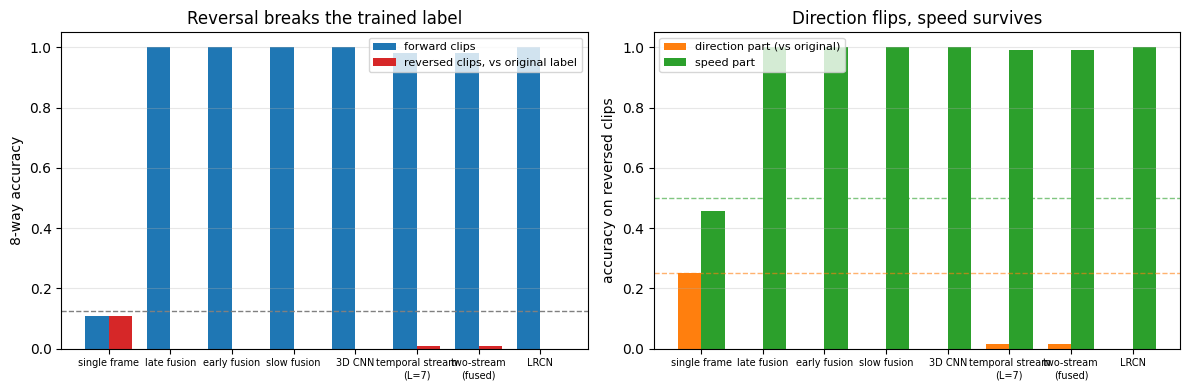

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
xs = np.arange(len(ORDER)); wd = 0.38
labels = [DISPLAY.get(n, n).replace(' (', '\n(') for n in ORDER]
axes[0].bar(xs - wd / 2, [table[n][0] for n in ORDER], wd, color='tab:blue', label='forward clips')
axes[0].bar(xs + wd / 2, [table[n][1] for n in ORDER], wd, color='tab:red', label='reversed clips, vs original label')
axes[0].axhline(1 / 8, ls='--', color='0.5', lw=1)
axes[0].set_ylabel('8-way accuracy'); axes[0].set_title('Reversal breaks the trained label'); axes[0].legend(fontsize=8)
axes[1].bar(xs - wd / 2, [table[n][3] for n in ORDER], wd, color='tab:orange', label='direction part (vs original)')
axes[1].bar(xs + wd / 2, [table[n][4] for n in ORDER], wd, color='tab:green', label='speed part')
axes[1].axhline(1 / 4, ls='--', color='tab:orange', lw=1, alpha=0.6); axes[1].axhline(1 / 2, ls='--', color='tab:green', lw=1, alpha=0.6)
axes[1].set_ylabel('accuracy on reversed clips'); axes[1].set_title('Direction flips, speed survives'); axes[1].legend(fontsize=8)
for ax in axes:
    ax.set_xticks(xs); ax.set_xticklabels(labels, fontsize=7, rotation=0); ax.set_ylim(0, 1.05); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

### Widget 5: the reversed-clip prediction viewer

Drag `clip` through the test set. The top filmstrip is the clip as trained on, the bottom one is the same clip reversed, and the table lists what every model says about each. Look for the pattern: the motion-reading models answer the top strip with the true label and the bottom strip with its mirror image (left for right, down for up, same speed), while the single-frame model answers both with the same unrelated guess.

In [34]:
def reversed_viewer(clip=0):
    fig, axes = plt.subplots(2, T, figsize=(12, 3.4))
    show_filmstrip(axes[0], Xte[clip], label='forward')
    show_filmstrip(axes[1], Xte_rev[clip], label='reversed')
    for t in range(T):
        axes[0, t].set_title(f't = {t}', fontsize=8)
    plt.suptitle(f'clip {clip}: forward = {CLASS_NAMES[int(yte[clip])]}, reversed = {CLASS_NAMES[int(yte_rev[clip])]}', y=1.02)
    plt.tight_layout(); plt.show()
    print(f'{"model":24s} {"forward clip ->":>18s}   {"reversed clip ->":>18s}')
    for name in ORDER:
        pf, pr = CLASS_NAMES[int(preds_fwd[name][clip])], CLASS_NAMES[int(preds_rev[name][clip])]
        ok_f = 'ok ' if int(preds_fwd[name][clip]) == int(yte[clip]) else '   '
        ok_r = 'ok ' if int(preds_rev[name][clip]) == int(yte_rev[clip]) else '   '
        print(f'{DISPLAY.get(name, name):24s} {pf:>15s} {ok_f}  {pr:>15s} {ok_r}')

interact(reversed_viewer, clip=IntSlider(min=0, max=39, step=1, value=0, continuous_update=False));

interactive(children=(IntSlider(value=0, continuous_update=False, description='clip', max=39), Output()), _dom…

## 9. Explore and verify

The claims the three architectures rest on, checked once more in one place: that folding time into the batch is exactly a loop over frames, that a 3D kernel of extent $k_T$ shortens the clip by $k_T - 1$, that a temporal extent of 1 is a 2D convolution in disguise, that the from-scratch 3D convolution agrees with PyTorch on a fresh random case, that score fusion produces a probability vector, and that the LRCN's size does not depend on the clip length.

In [35]:
# 1. Folding time into the batch == looping over frames, exactly.
conv = nn.Conv2d(3, 8, 3)
clip = torch.randn(2, 5, 3, 32, 32)
N, T_, C_, H_, W_ = clip.shape
folded = conv(clip.reshape(N * T_, C_, H_, W_)).reshape(N, T_, 8, 30, 30)
looped = torch.stack([torch.stack([conv(clip[n, t][None])[0] for t in range(T_)]) for n in range(N)])
assert torch.allclose(folded, looped, atol=1e-6), 'folding is not equivalent to looping'
print('  folding time into the batch == looping over frames: max |diff| = '
      f'{(folded - looped).abs().max():.1e}')

# 2. A 3D kernel with temporal extent k reduces T by k-1 (valid convolution).
for k in (1, 3, 5):
    c3 = nn.Conv3d(3, 4, kernel_size=(k, 3, 3))
    out_T = c3(torch.randn(1, 3, 16, 32, 32)).shape[2]
    assert out_T == 16 - k + 1, f'temporal extent {k} gave T={out_T}'
    print(f'  3D kernel with temporal extent {k}: T 16 -> {out_T}')

# 3. A temporal extent of 1 is exactly a 2D convolution applied per frame.
c3_flat = nn.Conv3d(3, 4, kernel_size=(1, 3, 3), bias=False)
c2 = nn.Conv2d(3, 4, kernel_size=3, bias=False)
with torch.no_grad():
    c2.weight.copy_(c3_flat.weight[:, :, 0])
v = torch.randn(1, 3, 6, 32, 32)
a = c3_flat(v)[0].permute(1, 0, 2, 3)
b = c2(v[0].permute(1, 0, 2, 3))
assert torch.allclose(a, b, atol=1e-5), 'temporal extent 1 is not the same as 2D'
print(f'  temporal extent 1 == per-frame 2D convolution: max |diff| = {(a - b).abs().max():.1e}')
print('  so "time as another dimension" collapses to "time ignored" when the extent is 1')

# 4. The from-scratch 3D convolution on a fresh random case (float64).
x = torch.randn(1, 2, 6, 7, 7, dtype=torch.float64); w = torch.randn(3, 2, 3, 3, 3, dtype=torch.float64)
assert torch.allclose(conv3d_scratch(x, w, stride=2, padding=1), F.conv3d(x, w, stride=2, padding=1), atol=1e-10)
print('  conv3d_scratch == F.conv3d on a fresh case with stride 2 and padding 1')

# 5. Score fusion is a probability vector; the LRCN's parameter count is independent of T.
assert torch.allclose(fused_scores.sum(1), torch.ones(len(Xte), device=device), atol=1e-5)
assert count_params(LRCN()) == results['LRCN']['params']
with torch.no_grad():
    assert models['LRCN'](Xte[:2, :5]).shape == (2, N_CLASSES) and models['LRCN'](Xte[:2]).shape == (2, N_CLASSES)
print('  fused two-stream scores sum to 1; the LRCN accepts 5-frame and 8-frame clips with the same parameters')
print('\nall checks passed')

  folding time into the batch == looping over frames: max |diff| = 0.0e+00
  3D kernel with temporal extent 1: T 16 -> 16
  3D kernel with temporal extent 3: T 16 -> 14
  3D kernel with temporal extent 5: T 16 -> 12
  temporal extent 1 == per-frame 2D convolution: max |diff| = 0.0e+00
  so "time as another dimension" collapses to "time ignored" when the extent is 1
  conv3d_scratch == F.conv3d on a fresh case with stride 2 and padding 1
  fused two-stream scores sum to 1; the LRCN accepts 5-frame and 8-frame clips with the same parameters

all checks passed


### How many frames does the LRCN need?

The LRCN is the one model that emits a prediction after every frame, so it can answer a question the others cannot: how does accuracy grow with the number of frames seen? The sweep below evaluates the prediction at each timestep $t$, on forward clips and on reversed clips (against the original label). One frame gives chance, by construction. The printed `acc_per_t` line in section 6b says how fast accuracy grows from there: two frames, the first displacement, already give about 89%, three frames give essentially 100%, and the rest is confirmation. On reversed clips the curve against the original label goes the other way, down toward zero, as the LSTM becomes sure of the wrong direction.

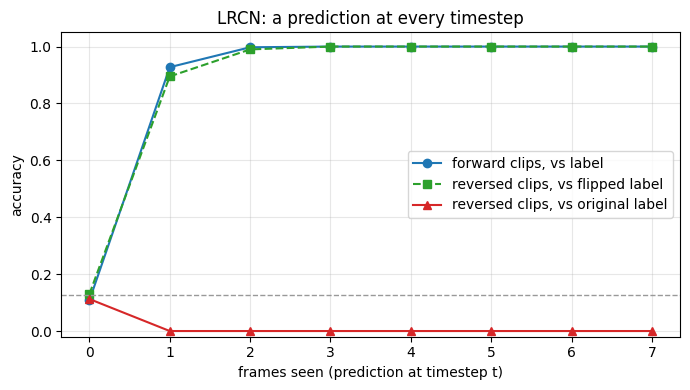

accuracy after t+1 frames, forward clips: 0.11 0.93 1.00 1.00 1.00 1.00 1.00 1.00


In [36]:
steps_fwd = predict_steps(models['LRCN'], Xte)
steps_rev = predict_steps(models['LRCN'], Xte_rev)
acc_t_fwd = (steps_fwd.argmax(2) == yte[:, None]).float().mean(0).cpu().numpy()
acc_t_rev_orig = (steps_rev.argmax(2) == yte[:, None]).float().mean(0).cpu().numpy()
acc_t_rev_flip = (steps_rev.argmax(2) == yte_rev[:, None]).float().mean(0).cpu().numpy()
prob_fwd = F.softmax(steps_fwd, 2).cpu().numpy()                    # precomputed for the widget
prob_rev = F.softmax(steps_rev, 2).cpu().numpy()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(T), acc_t_fwd, 'o-', color='tab:blue', label='forward clips, vs label')
ax.plot(range(T), acc_t_rev_flip, 's--', color='tab:green', label='reversed clips, vs flipped label')
ax.plot(range(T), acc_t_rev_orig, '^-', color='tab:red', label='reversed clips, vs original label')
ax.axhline(1 / N_CLASSES, ls='--', color='0.6', lw=1)
ax.set_xlabel('frames seen (prediction at timestep t)'); ax.set_ylabel('accuracy'); ax.set_ylim(-0.02, 1.05)
ax.set_title('LRCN: a prediction at every timestep'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('accuracy after t+1 frames, forward clips:', ' '.join(f'{a:.2f}' for a in acc_t_fwd))

Now the same thing under your control. Drag the slider and watch what changes.

### Widget 6: the LRCN's belief, frame by frame

Pick a clip and drag `t`. The bars are the LRCN's softmax at timestep $t$ for the forward clip (left) and the reversed clip (right). At $t = 0$ both are flat. At $t = 1$ the mass moves onto the true class on the left and onto its mirror class on the right for most clips (89% are already correct, by the printed per-timestep accuracies of section 6b), and from $t = 2$ on the two peaks only sharpen.

In [37]:
def lrcn_belief(clip=0, t=1):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
    for ax, probs, title, truth in [(axes[0], prob_fwd, 'forward clip', int(yte[clip])),
                                     (axes[1], prob_rev, 'reversed clip', int(yte_rev[clip]))]:
        cols = ['tab:green' if c == truth else '0.7' for c in range(N_CLASSES)]
        ax.bar(range(N_CLASSES), probs[clip, t], color=cols)
        ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
        ax.set_ylim(0, 1); ax.set_title(f'{title}: P(class) after frames 0..{t}   (green = true class)')
        ax.grid(alpha=0.3, axis='y')
    axes[0].set_ylabel('probability')
    plt.suptitle(f'clip {clip}: forward = {CLASS_NAMES[int(yte[clip])]}, reversed = {CLASS_NAMES[int(yte_rev[clip])]}', y=1.02)
    plt.tight_layout(); plt.show()

interact(lrcn_belief, clip=IntSlider(min=0, max=39, step=1, value=0), t=IntSlider(min=0, max=T - 1, step=1, value=1));

interactive(children=(IntSlider(value=0, description='clip', max=39), IntSlider(value=1, description='t', max=…

## Key takeaways

| Concept | Key takeaway |
|---|---|
| **Why video** | Motion carries information a single frame cannot; on our torus dataset every frame has the same distribution under every class, and the single-frame CNN measures at chance |
| **The taxonomy** | Time as **another dimension** (3D convolution; early and slow fusion are special cases) versus time as a **separate entity** (2D convolution per frame, plus flow or an RNN) |
| **Fusion** (Karpathy et al.) | Early and slow fusion detect local motion from the first layer and reach 100% within 300 steps; late fusion compares two global frame descriptions, sits at chance (loss $\ln 8$) for about 400 steps at a smaller learning rate, then also reaches 100% |
| **3D convolution** | One output voxel sees $k_T$ contiguous frames; cost is $k_T$ times the 2D kernel; each valid layer shortens the clip by $k_T - 1$; extent 1 is a 2D convolution |
| **Ji et al. (2012)** | 7@60x40 hardwired to 33 maps (7 gray, 7 + 7 gradients, 6 + 6 flow), 7x7x3 conv to 23*2 maps, subsample, 7x6x3 conv to 13*6 maps, subsample, 7x4 conv to a feature vector; every number reproduced |
| **Optical flow** | Lucas-Kanade solves $I_x u + I_y v + I_t = 0$ by least squares over a window; on our clips its sign is right for essentially every clip and its magnitude is right for small motions |
| **Two-stream** | Spatial stream on RGB, temporal stream on $2L$ flow channels (here $L$ difference frames), fused by averaging scores; an uninformative stream cannot hurt the argmax until its weight is nearly 1 |
| **LRCN** | Shared per-frame CNN, LSTM, prediction at every timestep; from scratch it sits on a chance plateau for about 200 steps, longer than the local-motion models, then learns to 100% within 600; its accuracy grows frame by frame, from chance after one frame to 89% after two and 100% after three |
| **Reversed clips** | Reversal flips direction predictions to the mirror class (accuracy 0, not chance) and leaves speed predictions intact: the slide's "depends on the task" |

### The architectures at a glance

| Model | Input | Where time is handled | Reads motion? | Reversal effect |
|---|---|---|---|---|
| single frame | one frame | nowhere | no | none (chance before and after) |
| late fusion | frames 0 and 7 | first FC layer | yes, globally, after a long plateau | direction flips |
| early fusion | $3T$ channels | first convolution | yes, locally | direction flips |
| slow fusion | 5D clip | 3D convs, $8 \to 3 \to 2 \to 1$ | yes | direction flips |
| 3D CNN | 5D clip | 3x3x3 convs + 3D pooling | yes | direction flips |
| two-stream | RGB frame + $L$ differences | in the flow / difference input | yes (temporal stream) | direction flips |
| LRCN | per-frame CNN features | LSTM over time | yes, after a plateau, given the budget | direction flips, visible frame by frame |

## Exercises

1. **The homework from the slides.** What happens if you train a model on normal videos and run inference on a reversed video? Use the table in section 8 to answer separately for the direction task and the speed task, and then say which of the two a tennis forehand resembles and which walking-versus-jumping resembles. *Answer from our runs: every motion-reading model drops to about 0 against the original label on reversed clips and keeps its forward accuracy against the flipped label; its speed accuracy is unchanged. A forehand is a direction-like task (the reversed clip is a different action); walking versus jumping is speed-like (reversal preserves the label).*

2. **A static distractor.** Add a second shape to `make_clips` that does not move, so that a model must first find which shape moves. Retrain everything and report the table. *In our runs, with the budgets used in this notebook, the local-motion models barely noticed the distractor: early fusion 0.988, slow fusion 0.998, the 3D CNN 1.000 and the temporal stream 0.957. The two models that compare global frame descriptions did not leave their plateau within budget: late fusion 0.108 after 1000 steps and the LRCN 0.132 after 600. A static shape makes every global description less about the moving one, which lengthens exactly the plateau sections 3 and 6 describe; a longer budget is the first thing to try.*

3. **Real flow in the temporal stream.** Replace `difference_stack` with the Lucas-Kanade flow of section 4c, giving the temporal stream $2L$ channels as in the paper. Does the flow input train faster or slower than the difference input, and does the fast-speed class, whose flow is underestimated, suffer?

4. **Learned fusion.** Section 5b averaged two softmax vectors. Concatenate the two streams' 1024-dimensional features instead and train a linear layer on top. Measure the accuracy, then repeat after replacing the spatial stream's input with a frame from a *different* clip: a learned fusion can learn to ignore a useless stream, an average cannot.

5. **Depth versus temporal extent.** Build a 3D CNN with valid (unpadded) temporal convolutions of extent 3 and count how many you can stack on an 8-frame clip before the time axis vanishes; then swap in temporal padding and see how the accuracy and the parameter count change.

6. **Which frames for late fusion?** `LateFusion` takes the frame indices it compares. Train it on frames $(0, 1)$, $(0, 3)$ and $(0, 7)$ and report the accuracy on the slow and on the fast clips separately. On a torus, a fast shape moves 21 pixels in 7 frames, which looks like 11 pixels the other way: which pair of frames is ambiguous, and does the model get it wrong in the way you expect?

7. **How long is the plateau?** Sections 3 and 6 showed that the two global-comparison models sit at chance for a few hundred steps and then take off. Train late fusion and the LRCN at learning rates $10^{-3}$, $2 \cdot 10^{-3}$ and $3 \cdot 10^{-3}$ for 1000 and 600 steps respectively, and record the step at which the training loss first drops below 2.0. *In our runs the LRCN left the plateau near step 300 at both $10^{-3}$ and $2 \cdot 10^{-3}$ and had not left it after 600 steps at $3 \cdot 10^{-3}$; late fusion left it near step 500 at $10^{-3}$, between steps 1000 and 1100 at $2 \cdot 10^{-3}$, and near step 400 at $3 \cdot 10^{-3}$. The plateau length is not monotonic in the learning rate: leaving a plateau whose gradient is tiny is a matter of when the optimizer happens to find the way off, so when a model sits at chance, sweep both the budget and the learning rate before concluding that it cannot learn.*